<a href="https://colab.research.google.com/github/5ahar-K/Project/blob/main/B29CW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Max Doppler Shift: 19.44 Hz
Image is loaded
True CFO: 0.1000, Estimated CFO: 0.1013
BER before CFO correction : 0.500306
BER after CFO correction  : 0.000000


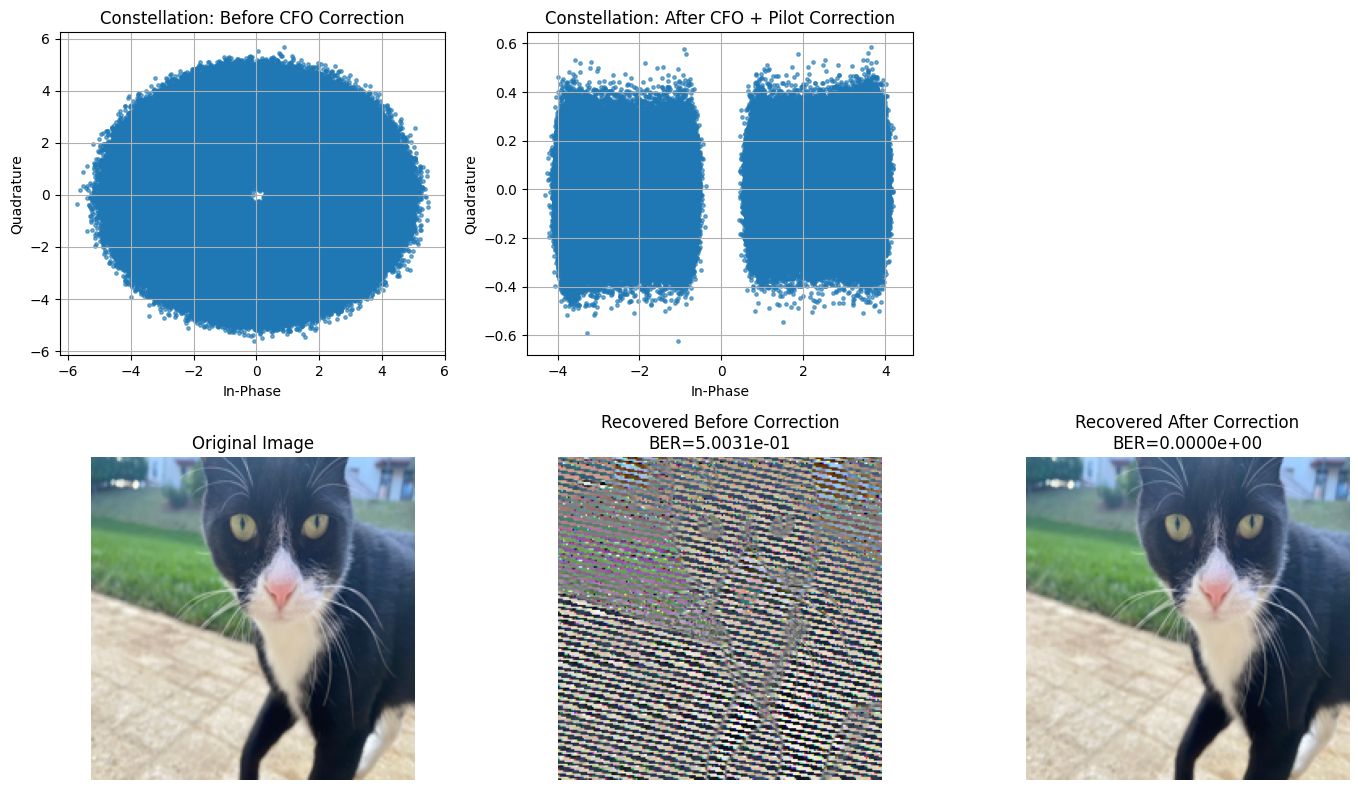

OFDM symbol duration     : 83.333 us
Total transmission time  : 1428.667 ms
Throughput before corr.  : 335771.82 bit/s
Throughput after corr.   : 671955.20 bit/s

================ FINAL SUMMARY ================
Metric                        Before CFO Corr.   After CFO Corr.
----------------------------------------------------------------
BER                               5.003062e-01      0.000000e+00
Throughput (bit/s)                   335771.82         671955.20
Estimated CFO                              N/A          0.101319
True CFO                                   N/A          0.100000

================ SIMULATION CASES TABLE ================
Case  Description                                         Mod       SNR     Speed       CFO       BER Before     BER After      Thr Before     Thr After      
--------------------------------------------------------------------------------------------------------------------------------------------------------------
0     Current
BPSK Case

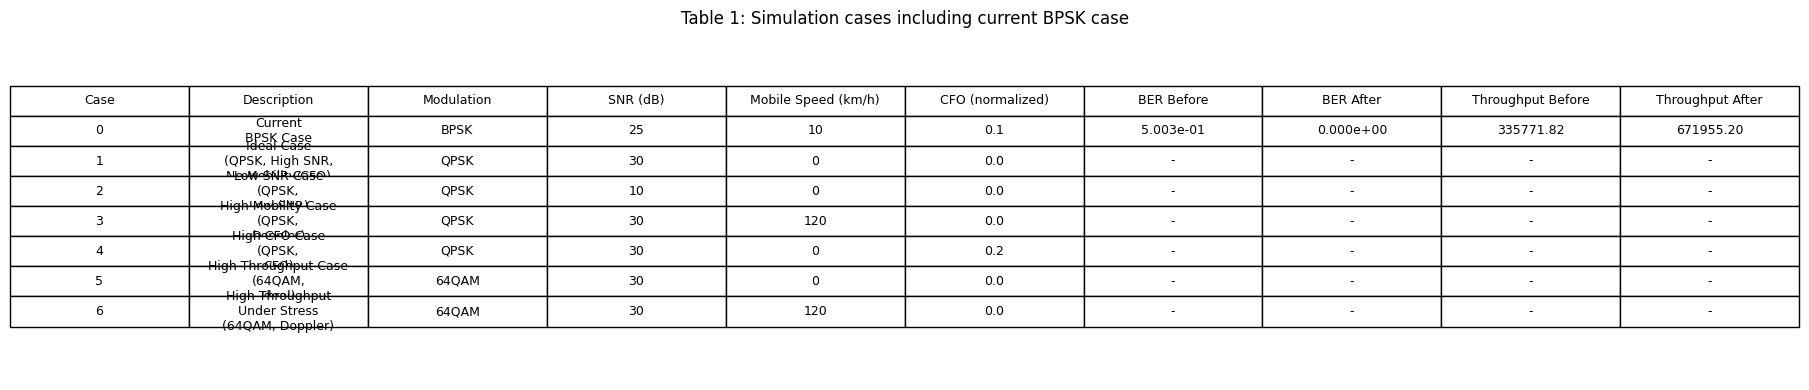

In [ ]:
from PIL import Image
import tensorflow as tf
from scipy.spatial import cKDTree
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np

# ========================================================================
# 1. SIMULATION PARAMETERS
# ========================================================================

# -- OFDM Parameters --
mod_method = "BPSK"      # Modulation scheme example.
n_fft = 64               # FFT size, representing the number of subcarriers per OFDM symbol.
n_cpe = 16               # Cyclic Prefix length, protects against Inter-Symbol Interference (ISI).

# -- Channel --
snr = 25  # Signal-to-Noise Ratio in dB. This is not default.

# -- 5G & Doppler Physical Parameters --
subcarrier_spacing = 15e3  # Subcarrier spacing in Hz (e.g., 15 kHz for a 5G NR-like system).
sampling_rate = n_fft * subcarrier_spacing  # The required sample rate of the system.
carrier_freq = 2.1e9  # Carrier frequency in Hz (e.g., 2.1 GHz).
mobile_speed = 10    # Speed of the receiver in km/h.

# Calculate the maximum Doppler shift based on the physical parameters.
c = 3e8  # Speed of light in m/s.
speed_ms = mobile_speed * 1000 / 3600  # Convert speed to m/s.
max_doppler_shift = (speed_ms / c) * carrier_freq
print(f"Max Doppler Shift: {max_doppler_shift:.2f} Hz")

# -- CFO Parameter --
# Normalized Carrier Frequency Offset. This simulates the frequency
# mismatch between the transmitter and receiver's local oscillators.
cfo_normalized = 0.1

# -- Pilot Parameters --
# Pilots are known symbols inserted into the data stream to help the receiver
# track phase changes and other channel variations.
pilot_spacing = 8        # Insert a pilot on every 8th subcarrier.
pilot_val = 1 + 1j       # The fixed complex value of the pilot symbols.

# A list of supported modulation methods.
mod_methods = ["BPSK", "QPSK", "8PSK", "16QAM", "32QAM", "64QAM"]



# ========================================================================
# 2. TRANSMITTER: DATA PREPARATION & MODULATION
# ========================================================================

# -- Source Data to Binary Stream --
# Load an image to use as the data source.
im_full = np.array(Image.open("cat.jpeg"))
im = np.array(
    Image.fromarray(im_full).resize((200, 200), resample=Image.BICUBIC)
)
print("Image is loaded")

# Convert the 8-bit pixel values (0-255) into a stream of binary characters.
im_bin = np.unpackbits(im.astype(np.uint8).ravel(), bitorder="big").astype(np.uint8)


# -- Binary Stream to Integer Symbols --
# Calculate how many zeros we need to add to make the bit stream length a
# multiple of the modulation order. This is called padding.
if mod_method not in mod_methods:
    raise ValueError(f"Unsupported modulation method: {mod_method}")

mod_order=mod_methods.index(mod_method)+1
zero_bits= -len(im_bin) % mod_order
padded= np.hstack([im_bin,np.zeros(zero_bits,dtype=np.uint8)])

groups= padded.reshape(-1, mod_order)
weights= (2**np.arange(mod_order-1, -1, -1)).astype(np.uint8)
sym_idx= groups.dot(weights).astype(int)
# Symbol Modulation
def symbol_book(mod_method):
    if mod_method == "BPSK":
        const = np.array([-1+0j, 1+0j], dtype=np.complex64)

    elif mod_method == "QPSK":
        const = np.array([1+1j, -1+1j, -1-1j, 1-1j], dtype=np.complex64)

    elif mod_method == "8PSK":
        rot = np.exp(1j * 2 * np.pi / 8)
        const = np.power(rot, np.arange(8)).astype(np.complex64)

    elif mod_method == "16QAM":
        nums = np.array([-3, -1, 1, 3], dtype=np.float32)
        const = np.array([i + 1j*q for i in nums for q in nums], dtype=np.complex64)

    elif mod_method == "32QAM":
        real_nums = np.array([-7, -5, -3, -1, 1, 3, 5, 7], dtype=np.float32)
        im_nums = np.array([-3, -1, 1, 3], dtype=np.float32)
        const = np.array([a + 1j*b for a in real_nums for b in im_nums], dtype=np.complex64)

    elif mod_method == "64QAM":
        nums = np.array([-7, -5, -3, -1, 1, 3, 5, 7], dtype=np.float32)
        const = np.array([a + 1j*b for a in nums for b in nums], dtype=np.complex64)

    else:
        raise ValueError(f"Unsupported modulation method: {mod_method}")

    const = const / np.sqrt(np.mean(np.abs(const) ** 2))
    return const

sym_map = symbol_book(mod_method)
modulated_symbols = sym_map[sym_idx]

# ========================================================================
# 3. TRANSMITTER: OFDM SYMBOL GENERATION
# ========================================================================


# -- Preamble Generation  --
# Generate a preamble. Example: Schmidl & Cox.
rand = np.random.default_rng(seed=67)

preamble_freq = np.zeros(n_fft, dtype=np.complex64)
active_preamble_idx = np.arange(0, n_fft, 2)   # even subcarriers only
preamble_freq[active_preamble_idx] = rand.choice(sym_map, size=len(active_preamble_idx))

preamble = np.fft.ifft(preamble_freq).astype(np.complex64)
preamble = preamble / np.sqrt(np.mean(np.abs(preamble) ** 2))

preamble_freq = np.fft.fft(preamble)

preamble_cp = np.hstack([preamble[-n_cpe:], preamble]).astype(np.complex64)


#Pilot
pilot_idx= np.arange(0,n_fft,pilot_spacing)
data_idx= np.setdiff1d(np.arange(n_fft), pilot_idx)
num_data_subcarriers= len(data_idx)
pad= -len(modulated_symbols)% num_data_subcarriers
modulated_syms_padded= np.hstack([modulated_symbols, np.zeros(pad, dtype=np.complex64)])
num_ofdm_syms= len(modulated_syms_padded)// num_data_subcarriers
#arrangement of symbols into OFDM symbols
data_matrix= modulated_syms_padded.reshape(num_ofdm_syms, num_data_subcarriers)
ofdm_matrix= np.zeros((num_ofdm_syms, n_fft), dtype=np.complex64)
ofdm_matrix[:, pilot_idx]= pilot_val
ofdm_matrix[:, data_idx]= data_matrix
#IFFT and CP
ofdm_time= np.fft.ifft(ofdm_matrix, axis=1)
ofdm_time_cp= np.hstack([ofdm_time[:,-n_cpe:], ofdm_time]).reshape(-1).astype(np.complex64)
x_t= np.hstack([preamble_cp, ofdm_time_cp]).astype(np.complex64)
# ========================================================================
# 4. CHANNEL SIMULATION
# ========================================================================


# -- Time-Varying Rayleigh Fading Channel with Jakes Doppler --
# In MATLAB, it is comm.RayleighChannel

def jakes_fading(num_samples, max_doppler_shift, sampling_rate, num_sin=4):
    t = np.arange(num_samples) / sampling_rate
    phi= 2 * np.pi * np.random.rand(num_sin + 1)  # Random initial phase for each sine
    alpa= 2*np.pi* np.arange(num_sin+1) / (num_sin+1)  # Uniformly spaced angles of arrival
    fading = np.zeros(num_samples, dtype=np.complex64)
    for k in range(1, num_sin+1):
        fk = 2*np.pi* max_doppler_shift * np.cos(alpa[k])
        fading += np.exp(1j * (fk * t + phi[k]))
    fading /= np.sqrt(num_sin)
    return fading.astype(np.complex64)


path_delays_s = np.array([0.0, 0.2e-7, 0.5e-7], dtype=np.float64)
avg_path_gains_db = np.array([0.0, -3.0, -6.0], dtype=np.float64)

sample_delays = np.round(path_delays_s * sampling_rate).astype(int)
tap_gains_lin = 10 ** (avg_path_gains_db / 20.0)

num_samples=len(x_t)
y= np.zeros(num_samples,dtype=np.complex64)
for gain, delay in zip(tap_gains_lin, sample_delays):
    delayed= np.zeros(num_samples, dtype=np.complex64)
    if delay< num_samples:
        delayed[delay:]=x_t[:num_samples-delay]

    h_t= gain*jakes_fading(num_samples, max_doppler_shift, sampling_rate)
    y+= h_t* delayed

#AWGN
P_signal= np.mean(np.abs(y)**2)
P_noise= P_signal / (10**(snr/10))
noise= np.sqrt(P_noise/2)* (np.random.randn(num_samples) + 1j* np.random.randn(num_samples)).astype(np.complex64)
y+= noise

n= np.arange(num_samples)
y_rx= y* np.exp(1j* 2* np.pi* cfo_normalized* n/ n_fft).astype(np.complex64)



# ========================================================================
# 5. RECEIVER: OFDM DEMODULATION & DATA RECOVERY
# ========================================================================
def ints_to_bits(indices, bits_per_symbol):
    indices = np.asarray(indices).astype(int)
    bits = ((indices[:, None] & (1 << np.arange(bits_per_symbol - 1, -1, -1))) > 0)
    return bits.astype(np.uint8).ravel()

#Coarse CFO estimation using the preamble
#time domain   |CP + PREAMBLE | CP + OFDM1 | CP + OFDM2 | CP + OFDM3 |
rx_preamble_cp= y_rx[:n_fft+n_cpe]  #CP +preamble
rx_preamble= rx_preamble_cp[n_cpe:]  #preamble
first_half= rx_preamble[:n_fft//2]
second_half= rx_preamble[n_fft//2:]
S= np.sum(np.conjugate(first_half)* second_half)
cfo_est= np.angle(S)/np.pi
print(f"True CFO: {cfo_normalized:.4f}, Estimated CFO: {cfo_est:.4f}")

# Correct CFO
n = np.arange(len(y_rx))
if np.abs(cfo_est) > 1e-6:
    y_rx_corr = y_rx * np.exp(-1j * 2 * np.pi * cfo_est * n / n_fft)
else:
    y_rx_corr = y_rx.copy()

y_rx_uncorr = y_rx.copy()



#OFDM Demodulation
payload_corr = y_rx_corr[len(preamble_cp):]
payload_uncorr = y_rx_uncorr[len(preamble_cp):]

rx_blocks_corr = payload_corr.reshape(num_ofdm_syms, n_fft + n_cpe)
rx_blocks_uncorr = payload_uncorr.reshape(num_ofdm_syms, n_fft + n_cpe)

rx_fd_corr = np.fft.fft(rx_blocks_corr[:, n_cpe:], axis=1)
rx_fd_uncorr = np.fft.fft(rx_blocks_uncorr[:, n_cpe:], axis=1)

# Channel estimation
rx_preamble_corr_cp = y_rx_corr[: n_cpe + n_fft]
rx_preamble_corr = rx_preamble_corr_cp[n_cpe:]
Y_pre = np.fft.fft(rx_preamble_corr)
eps = 1e-12

H_est = np.zeros_like(Y_pre, dtype=np.complex64)
H_est[active_preamble_idx] = Y_pre[active_preamble_idx] / (preamble_freq[active_preamble_idx] + eps)

all_idx = np.arange(n_fft)
H_real = np.interp(all_idx, active_preamble_idx, H_est[active_preamble_idx].real)
H_imag = np.interp(all_idx, active_preamble_idx, H_est[active_preamble_idx].imag)
H_est = (H_real + 1j * H_imag).astype(np.complex64)

rx_eq_corr = rx_fd_corr / (H_est[None, :] + eps) #equalization
rx_eq_uncorr = rx_fd_uncorr / (H_est[None, :] + eps)

# Fine CFO correction using pilots
pilot_rx_corr = rx_eq_corr[:, pilot_idx]
pilot_phase_corr = np.angle(np.mean(pilot_rx_corr / pilot_val, axis=1))
rx_eq_corr_phase = rx_eq_corr * np.exp(-1j * pilot_phase_corr[:, None])

rx_data_corr = rx_eq_corr_phase[:, data_idx].ravel()[: len(modulated_symbols)]
rx_data_uncorr = rx_eq_uncorr[:, data_idx].ravel()[: len(modulated_symbols)]

# Nearest-neighbour symbol detection
tree = cKDTree(np.column_stack([symbol_book(mod_method).real, symbol_book(mod_method).imag]))

_, det_idx_corr = tree.query(np.column_stack([rx_data_corr.real, rx_data_corr.imag]), k=1)
_, det_idx_uncorr = tree.query(np.column_stack([rx_data_uncorr.real, rx_data_uncorr.imag]), k=1)

rx_bits_corr = ints_to_bits(det_idx_corr, mod_order)[: len(im_bin)]
rx_bits_uncorr = ints_to_bits(det_idx_uncorr, mod_order)[: len(im_bin)]

ber_corr = np.mean(rx_bits_corr != im_bin)
ber_uncorr = np.mean(rx_bits_uncorr != im_bin)

print(f"BER before CFO correction : {ber_uncorr:.6f}")
print(f"BER after CFO correction  : {ber_corr:.6f}")

# Reconstructing image
rx_bytes_corr = np.packbits(rx_bits_corr)
rx_bytes_uncorr = np.packbits(rx_bits_uncorr)

im_rec_corr = rx_bytes_corr[: im.size].reshape(im.shape)
im_rec_uncorr = rx_bytes_uncorr[: im.size].reshape(im.shape)



# ========================================================================
# 6. DATA AND PERFORMANCE VISUALIZATION
# ========================================================================

plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.scatter(rx_data_uncorr.real, rx_data_uncorr.imag, s=6, alpha=0.6)
plt.title("Constellation: Before CFO Correction")
plt.xlabel("In-Phase")
plt.ylabel("Quadrature")
plt.grid(True)

plt.subplot(2, 3, 2)
plt.scatter(rx_data_corr.real, rx_data_corr.imag, s=6, alpha=0.6)
plt.title("Constellation: After CFO + Pilot Correction")
plt.xlabel("In-Phase")
plt.ylabel("Quadrature")
plt.grid(True)

# plt.subplot(2, 3, 3)
# plt.plot(np.real(y_rx[:400]), label="Real")
# plt.plot(np.imag(y_rx[:400]), label="Imag", alpha=0.8)
# plt.title("Received Signal (first 400 samples)")
# plt.legend()
# plt.grid(True)

plt.subplot(2, 3, 4)
plt.imshow(im)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(im_rec_uncorr.astype(np.uint8))
plt.title(f"Recovered Before Correction\nBER={ber_uncorr:.4e}")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(im_rec_corr.astype(np.uint8))
plt.title(f"Recovered After Correction\nBER={ber_corr:.4e}")
plt.axis("off")

plt.tight_layout()
plt.show()

# ========================================================================
# 7. PERFORMANCE ANALYSIS & REPORTING
# ========================================================================
#  Calculate and display the final performance metrics.


# -- Throughput Calculation --

ofdm_symbol_duration = (n_fft + n_cpe) / sampling_rate
total_tx_time = len(x_t) / sampling_rate

throughput_uncorr = len(im_bin) * (1 - ber_uncorr) / total_tx_time
throughput_corr = len(im_bin) * (1 - ber_corr) / total_tx_time

print(f"OFDM symbol duration     : {ofdm_symbol_duration*1e6:.3f} us")
print(f"Total transmission time  : {total_tx_time*1e3:.3f} ms")
print(f"Throughput before corr.  : {throughput_uncorr:.2f} bit/s")
print(f"Throughput after corr.   : {throughput_corr:.2f} bit/s")

# -- Final Summary Table --

print("\n================ FINAL SUMMARY ================")
print(f"{'Metric':<28}{'Before CFO Corr.':>18}{'After CFO Corr.':>18}")
print("-" * 64)
print(f"{'BER':<28}{ber_uncorr:>18.6e}{ber_corr:>18.6e}")
print(f"{'Throughput (bit/s)':<28}{throughput_uncorr:>18.2f}{throughput_corr:>18.2f}")
print(f"{'Estimated CFO':<28}{'N/A':>18}{cfo_est:>18.6f}")
print(f"{'True CFO':<28}{'N/A':>18}{cfo_normalized:>18.6f}")
print("=" * 64)
simulation_cases = [
    {
        "Case": 0,
        "Description": "Current\nBPSK Case",
        "Modulation": mod_method,
        "SNR (dB)": snr,
        "Mobile Speed (km/h)": mobile_speed,
        "CFO (normalized)": cfo_normalized,
        "BER Before CFO Corr.": ber_uncorr,
        "BER After CFO Corr.": ber_corr,
        "Throughput Before (bit/s)": throughput_uncorr,
        "Throughput After (bit/s)": throughput_corr,
    },
    {
        "Case": 1,
        "Description": "Ideal Case\n(QPSK, High SNR,\nNo Mobility/CFO)",
        "Modulation": "QPSK",
        "SNR (dB)": 30,
        "Mobile Speed (km/h)": 0,
        "CFO (normalized)": 0.0,
        "BER Before CFO Corr.": np.nan,
        "BER After CFO Corr.": np.nan,
        "Throughput Before (bit/s)": np.nan,
        "Throughput After (bit/s)": np.nan,
    },
    {
        "Case": 2,
        "Description": "Low SNR Case\n(QPSK,\nLow SNR)",
        "Modulation": "QPSK",
        "SNR (dB)": 10,
        "Mobile Speed (km/h)": 0,
        "CFO (normalized)": 0.0,
        "BER Before CFO Corr.": np.nan,
        "BER After CFO Corr.": np.nan,
        "Throughput Before (bit/s)": np.nan,
        "Throughput After (bit/s)": np.nan,
    },
    {
        "Case": 3,
        "Description": "High Mobility Case\n(QPSK,\nDoppler)",
        "Modulation": "QPSK",
        "SNR (dB)": 30,
        "Mobile Speed (km/h)": 120,
        "CFO (normalized)": 0.0,
        "BER Before CFO Corr.": np.nan,
        "BER After CFO Corr.": np.nan,
        "Throughput Before (bit/s)": np.nan,
        "Throughput After (bit/s)": np.nan,
    },
    {
        "Case": 4,
        "Description": "High CFO Case\n(QPSK,\nCFO)",
        "Modulation": "QPSK",
        "SNR (dB)": 30,
        "Mobile Speed (km/h)": 0,
        "CFO (normalized)": 0.2,
        "BER Before CFO Corr.": np.nan,
        "BER After CFO Corr.": np.nan,
        "Throughput Before (bit/s)": np.nan,
        "Throughput After (bit/s)": np.nan,
    },
    {
        "Case": 5,
        "Description": "High Throughput Case\n(64QAM,\nIdeal)",
        "Modulation": "64QAM",
        "SNR (dB)": 30,
        "Mobile Speed (km/h)": 0,
        "CFO (normalized)": 0.0,
        "BER Before CFO Corr.": np.nan,
        "BER After CFO Corr.": np.nan,
        "Throughput Before (bit/s)": np.nan,
        "Throughput After (bit/s)": np.nan,
    },
    {
        "Case": 6,
        "Description": "High Throughput\nUnder Stress\n(64QAM, Doppler)",
        "Modulation": "64QAM",
        "SNR (dB)": 30,
        "Mobile Speed (km/h)": 120,
        "CFO (normalized)": 0.0,
        "BER Before CFO Corr.": np.nan,
        "BER After CFO Corr.": np.nan,
        "Throughput Before (bit/s)": np.nan,
        "Throughput After (bit/s)": np.nan,
    },
]


print("\n================ SIMULATION CASES TABLE ================")
header = (
    f"{'Case':<6}"
    f"{'Description':<52}"
    f"{'Mod':<10}"
    f"{'SNR':<8}"
    f"{'Speed':<12}"
    f"{'CFO':<10}"
    f"{'BER Before':<15}"
    f"{'BER After':<15}"
    f"{'Thr Before':<15}"
    f"{'Thr After':<15}"
)
print(header)
print("-" * len(header))

for row in simulation_cases:
    ber_b = f"{row['BER Before CFO Corr.']:.3e}" if not np.isnan(row["BER Before CFO Corr."]) else "-"
    ber_a = f"{row['BER After CFO Corr.']:.3e}" if not np.isnan(row["BER After CFO Corr."]) else "-"
    thr_b = f"{row['Throughput Before (bit/s)']:.2f}" if not np.isnan(row["Throughput Before (bit/s)"]) else "-"
    thr_a = f"{row['Throughput After (bit/s)']:.2f}" if not np.isnan(row["Throughput After (bit/s)"]) else "-"

    print(
        f"{row['Case']:<6}"
        f"{row['Description']:<52.52}"
        f"{row['Modulation']:<10}"
        f"{row['SNR (dB)']:<8}"
        f"{row['Mobile Speed (km/h)']:<12}"
        f"{row['CFO (normalized)']:<10}"
        f"{ber_b:<15}"
        f"{ber_a:<15}"
        f"{thr_b:<15}"
        f"{thr_a:<15}"
    )

# Optional: nice matplotlib table
fig, ax = plt.subplots(figsize=(18, 4))
ax.axis("off")

table_rows = []
for row in simulation_cases:
    table_rows.append([
        row["Case"],
        row["Description"],
        row["Modulation"],
        row["SNR (dB)"],
        row["Mobile Speed (km/h)"],
        row["CFO (normalized)"],
        f"{row['BER Before CFO Corr.']:.3e}" if not np.isnan(row["BER Before CFO Corr."]) else "-",
        f"{row['BER After CFO Corr.']:.3e}" if not np.isnan(row["BER After CFO Corr."]) else "-",
        f"{row['Throughput Before (bit/s)']:.2f}" if not np.isnan(row["Throughput Before (bit/s)"]) else "-",
        f"{row['Throughput After (bit/s)']:.2f}" if not np.isnan(row["Throughput After (bit/s)"]) else "-",
    ])

col_labels = [
    "Case",
    "Description",
    "Modulation",
    "SNR (dB)",
    "Mobile Speed (km/h)",
    "CFO (normalized)",
    "BER Before",
    "BER After",
    "Throughput Before",
    "Throughput After",
]

tbl = ax.table(
    cellText=table_rows,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)

plt.title("Table 1: Simulation cases including current BPSK case")
plt.tight_layout()
plt.show()

Max Doppler Shift: 19.44 Hz
Image is loaded
True CFO: 0.1000, Estimated CFO: 0.0993
BER before CFO correction : 0.499759
BER after CFO correction  : 0.000001


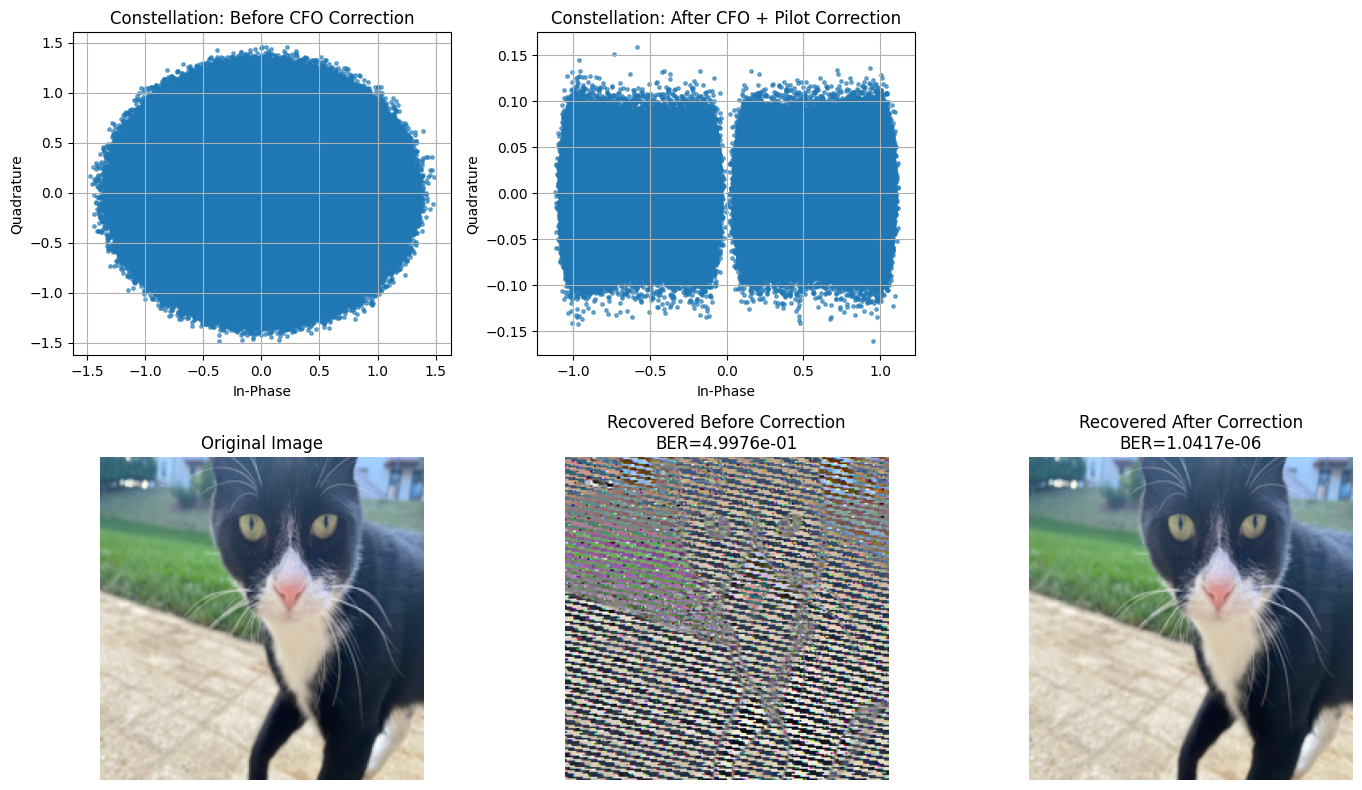

OFDM symbol duration     : 83.333 us
Total transmission time  : 1428.667 ms
Throughput before corr.  : 336139.29 bit/s
Throughput after corr.   : 671954.50 bit/s

================ FINAL SUMMARY ================
Metric                        Before CFO Corr.   After CFO Corr.
----------------------------------------------------------------
BER                               4.997594e-01      1.041667e-06
Throughput (bit/s)                   336139.29         671954.50
Estimated CFO                              N/A          0.099344
True CFO                                   N/A          0.100000

================ SIMULATION CASES TABLE ================
Case  Description                                         Mod       SNR     Speed       CFO       BER Before     BER After      Thr Before     Thr After      
--------------------------------------------------------------------------------------------------------------------------------------------------------------
0     Current
BPSK Case

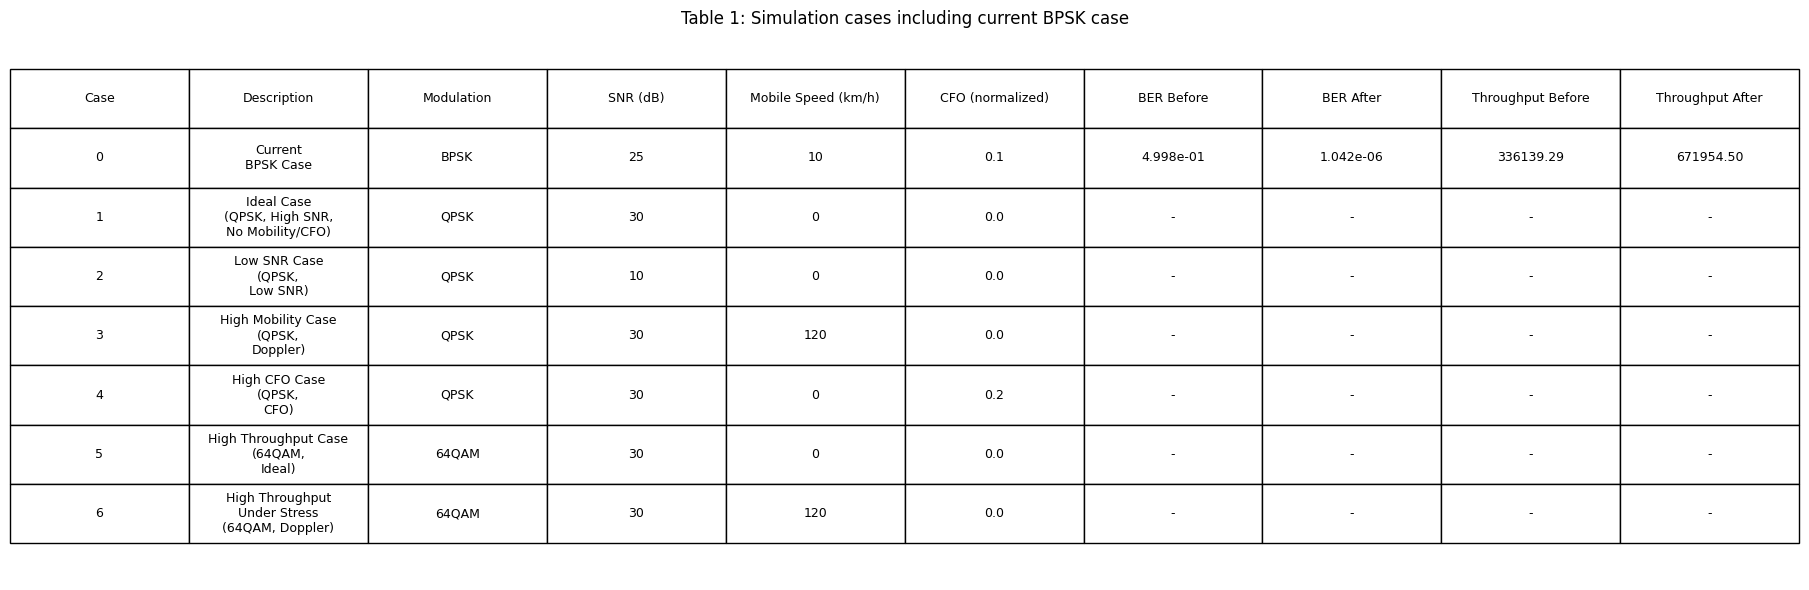

In [ ]:
from PIL import Image
import tensorflow as tf
from scipy.spatial import cKDTree
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np

# ========================================================================
# 1. SIMULATION PARAMETERS
# ========================================================================

# -- OFDM Parameters --
mod_method = "BPSK"      # Modulation scheme example.
n_fft = 64               # FFT size, representing the number of subcarriers per OFDM symbol.
n_cpe = 16               # Cyclic Prefix length, protects against Inter-Symbol Interference (ISI).

# -- Channel --
snr = 25  # Signal-to-Noise Ratio in dB. This is not default.

# -- 5G & Doppler Physical Parameters --
subcarrier_spacing = 15e3  # Subcarrier spacing in Hz (e.g., 15 kHz for a 5G NR-like system).
sampling_rate = n_fft * subcarrier_spacing  # The required sample rate of the system.
carrier_freq = 2.1e9  # Carrier frequency in Hz (e.g., 2.1 GHz).
mobile_speed = 10    # Speed of the receiver in km/h.

# Calculate the maximum Doppler shift based on the physical parameters.
c = 3e8  # Speed of light in m/s.
speed_ms = mobile_speed * 1000 / 3600  # Convert speed to m/s.
max_doppler_shift = (speed_ms / c) * carrier_freq
print(f"Max Doppler Shift: {max_doppler_shift:.2f} Hz")

# -- CFO Parameter --
# Normalized Carrier Frequency Offset. This simulates the frequency
# mismatch between the transmitter and receiver's local oscillators.
cfo_normalized = 0.1

# -- Pilot Parameters --
# Pilots are known symbols inserted into the data stream to help the receiver
# track phase changes and other channel variations.
pilot_spacing = 8        # Insert a pilot on every 8th subcarrier.
pilot_val = 1 + 1j       # The fixed complex value of the pilot symbols.

# A list of supported modulation methods.
mod_methods = ["BPSK", "QPSK", "8PSK", "16QAM", "32QAM", "64QAM"]



# ========================================================================
# 2. TRANSMITTER: DATA PREPARATION & MODULATION
# ========================================================================

# -- Source Data to Binary Stream --
# Load an image to use as the data source.
im_full = np.array(Image.open("cat.jpeg"))
im = np.array(
    Image.fromarray(im_full).resize((200, 200), resample=Image.BICUBIC)
)
print("Image is loaded")

# Convert the 8-bit pixel values (0-255) into a stream of binary characters.
im_bin = np.unpackbits(im.astype(np.uint8).ravel(), bitorder="big").astype(np.uint8)


# -- Binary Stream to Integer Symbols --
# Calculate how many zeros we need to add to make the bit stream length a
# multiple of the modulation order. This is called padding.
if mod_method not in mod_methods:
    raise ValueError(f"Unsupported modulation method: {mod_method}")

mod_order=mod_methods.index(mod_method)+1
zero_bits= -len(im_bin) % mod_order
padded= np.hstack([im_bin,np.zeros(zero_bits,dtype=np.uint8)])

groups= padded.reshape(-1, mod_order)
weights= (2**np.arange(mod_order-1, -1, -1)).astype(np.uint8)
sym_idx= groups.dot(weights).astype(int)
# Symbol Modulation
def symbol_book(mod_method):
    if mod_method == "BPSK":
        const = np.array([-1+0j, 1+0j], dtype=np.complex64)

    elif mod_method == "QPSK":
        const = np.array([1+1j, -1+1j, -1-1j, 1-1j], dtype=np.complex64)

    elif mod_method == "8PSK":
        rot = np.exp(1j * 2 * np.pi / 8)
        const = np.power(rot, np.arange(8)).astype(np.complex64)

    elif mod_method == "16QAM":
        nums = np.array([-3, -1, 1, 3], dtype=np.float32)
        const = np.array([i + 1j*q for i in nums for q in nums], dtype=np.complex64)

    elif mod_method == "32QAM":
        real_nums = np.array([-7, -5, -3, -1, 1, 3, 5, 7], dtype=np.float32)
        im_nums = np.array([-3, -1, 1, 3], dtype=np.float32)
        const = np.array([a + 1j*b for a in real_nums for b in im_nums], dtype=np.complex64)

    elif mod_method == "64QAM":
        nums = np.array([-7, -5, -3, -1, 1, 3, 5, 7], dtype=np.float32)
        const = np.array([a + 1j*b for a in nums for b in nums], dtype=np.complex64)

    else:
        raise ValueError(f"Unsupported modulation method: {mod_method}")

    const = const / np.sqrt(np.mean(np.abs(const) ** 2))
    return const

sym_map = symbol_book(mod_method)
modulated_symbols = sym_map[sym_idx]

# ========================================================================
# 3. TRANSMITTER: OFDM SYMBOL GENERATION
# ========================================================================


# -- Preamble Generation  --
# Generate a preamble. Example: Schmidl & Cox.
rand = np.random.default_rng(seed=67)

preamble_freq = np.zeros(n_fft, dtype=np.complex64)
active_preamble_idx = np.arange(0, n_fft, 2)   # even subcarriers only
preamble_freq[active_preamble_idx] = rand.choice(sym_map, size=len(active_preamble_idx))

preamble = np.fft.ifft(preamble_freq).astype(np.complex64)
preamble = preamble / np.sqrt(np.mean(np.abs(preamble) ** 2))

preamble_freq = np.fft.fft(preamble)

preamble_cp = np.hstack([preamble[-n_cpe:], preamble]).astype(np.complex64)


#Pilot
pilot_idx= np.arange(0,n_fft,pilot_spacing)
data_idx= np.setdiff1d(np.arange(n_fft), pilot_idx)
num_data_subcarriers= len(data_idx)
pad= -len(modulated_symbols)% num_data_subcarriers
modulated_syms_padded= np.hstack([modulated_symbols, np.zeros(pad, dtype=np.complex64)])
num_ofdm_syms= len(modulated_syms_padded)// num_data_subcarriers
#arrangement of symbols into OFDM symbols
data_matrix= modulated_syms_padded.reshape(num_ofdm_syms, num_data_subcarriers)
ofdm_matrix= np.zeros((num_ofdm_syms, n_fft), dtype=np.complex64)
ofdm_matrix[:, pilot_idx]= pilot_val
ofdm_matrix[:, data_idx]= data_matrix
#IFFT and CP
ofdm_time= np.fft.ifft(ofdm_matrix, axis=1)
ofdm_time_cp= np.hstack([ofdm_time[:,-n_cpe:], ofdm_time]).reshape(-1).astype(np.complex64)
x_t= np.hstack([preamble_cp, ofdm_time_cp]).astype(np.complex64)
# ========================================================================
# 4. CHANNEL SIMULATION
# ========================================================================


# -- Time-Varying Rayleigh Fading Channel with Jakes Doppler --
# In MATLAB, it is comm.RayleighChannel

def jakes_fading(num_samples, max_doppler_shift, sampling_rate, num_sin=4):
    t = np.arange(num_samples) / sampling_rate
    phi= 2 * np.pi * np.random.rand(num_sin + 1)  # Random initial phase for each sine
    alpa= 2*np.pi* np.arange(num_sin+1) / (num_sin+1)  # Uniformly spaced angles of arrival
    fading = np.zeros(num_samples, dtype=np.complex64)
    for k in range(1, num_sin+1):
        fk = 2*np.pi* max_doppler_shift * np.cos(alpa[k])
        fading += np.exp(1j * (fk * t + phi[k]))
    fading /= np.sqrt(num_sin)
    return fading.astype(np.complex64)


path_delays_s = np.array([0.0, 0.2e-7, 0.5e-7], dtype=np.float64)
avg_path_gains_db = np.array([0.0, -3.0, -6.0], dtype=np.float64)

sample_delays = np.round(path_delays_s * sampling_rate).astype(int)
tap_gains_lin = 10 ** (avg_path_gains_db / 20.0)

num_samples=len(x_t)
y= np.zeros(num_samples,dtype=np.complex64)
for gain, delay in zip(tap_gains_lin, sample_delays):
    delayed= np.zeros(num_samples, dtype=np.complex64)
    if delay< num_samples:
        delayed[delay:]=x_t[:num_samples-delay]

    h_t= gain*jakes_fading(num_samples, max_doppler_shift, sampling_rate)
    y+= h_t* delayed

#AWGN
P_signal= np.mean(np.abs(y)**2)
P_noise= P_signal / (10**(snr/10))
noise= np.sqrt(P_noise/2)* (np.random.randn(num_samples) + 1j* np.random.randn(num_samples)).astype(np.complex64)
y+= noise

n= np.arange(num_samples)
y_rx= y* np.exp(1j* 2* np.pi* cfo_normalized* n/ n_fft).astype(np.complex64)



# ========================================================================
# 5. RECEIVER: OFDM DEMODULATION & DATA RECOVERY
# ========================================================================
def ints_to_bits(indices, bits_per_symbol):
    indices = np.asarray(indices).astype(int)
    bits = ((indices[:, None] & (1 << np.arange(bits_per_symbol - 1, -1, -1))) > 0)
    return bits.astype(np.uint8).ravel()

#Coarse CFO estimation using the preamble
#time domain   |CP + PREAMBLE | CP + OFDM1 | CP + OFDM2 | CP + OFDM3 |
rx_preamble_cp= y_rx[:n_fft+n_cpe]  #CP +preamble
rx_preamble= rx_preamble_cp[n_cpe:]  #preamble
first_half= rx_preamble[:n_fft//2]
second_half= rx_preamble[n_fft//2:]
S= np.sum(np.conjugate(first_half)* second_half)
cfo_est= np.angle(S)/np.pi
print(f"True CFO: {cfo_normalized:.4f}, Estimated CFO: {cfo_est:.4f}")

# Correct CFO
n = np.arange(len(y_rx))
if np.abs(cfo_est) > 1e-6:
    y_rx_corr = y_rx * np.exp(-1j * 2 * np.pi * cfo_est * n / n_fft)
else:
    y_rx_corr = y_rx.copy()

y_rx_uncorr = y_rx.copy()



#OFDM Demodulation
payload_corr = y_rx_corr[len(preamble_cp):]
payload_uncorr = y_rx_uncorr[len(preamble_cp):]

rx_blocks_corr = payload_corr.reshape(num_ofdm_syms, n_fft + n_cpe)
rx_blocks_uncorr = payload_uncorr.reshape(num_ofdm_syms, n_fft + n_cpe)

rx_fd_corr = np.fft.fft(rx_blocks_corr[:, n_cpe:], axis=1)
rx_fd_uncorr = np.fft.fft(rx_blocks_uncorr[:, n_cpe:], axis=1)

# Channel estimation
rx_preamble_corr_cp = y_rx_corr[: n_cpe + n_fft]
rx_preamble_corr = rx_preamble_corr_cp[n_cpe:]
Y_pre = np.fft.fft(rx_preamble_corr)
eps = 1e-12

H_est = np.zeros_like(Y_pre, dtype=np.complex64)
H_est[active_preamble_idx] = Y_pre[active_preamble_idx] / (preamble_freq[active_preamble_idx] + eps)

all_idx = np.arange(n_fft)
H_real = np.interp(all_idx, active_preamble_idx, H_est[active_preamble_idx].real)
H_imag = np.interp(all_idx, active_preamble_idx, H_est[active_preamble_idx].imag)
H_est = (H_real + 1j * H_imag).astype(np.complex64)

rx_eq_corr = rx_fd_corr / (H_est[None, :] + eps) #equalization
rx_eq_uncorr = rx_fd_uncorr / (H_est[None, :] + eps)

# Fine CFO correction using pilots
pilot_rx_corr = rx_eq_corr[:, pilot_idx]
pilot_phase_corr = np.angle(np.mean(pilot_rx_corr / pilot_val, axis=1))
rx_eq_corr_phase = rx_eq_corr * np.exp(-1j * pilot_phase_corr[:, None])

rx_data_corr = rx_eq_corr_phase[:, data_idx].ravel()[: len(modulated_symbols)]
rx_data_uncorr = rx_eq_uncorr[:, data_idx].ravel()[: len(modulated_symbols)]

# Nearest-neighbour symbol detection
tree = cKDTree(np.column_stack([symbol_book(mod_method).real, symbol_book(mod_method).imag]))

_, det_idx_corr = tree.query(np.column_stack([rx_data_corr.real, rx_data_corr.imag]), k=1)
_, det_idx_uncorr = tree.query(np.column_stack([rx_data_uncorr.real, rx_data_uncorr.imag]), k=1)

rx_bits_corr = ints_to_bits(det_idx_corr, mod_order)[: len(im_bin)]
rx_bits_uncorr = ints_to_bits(det_idx_uncorr, mod_order)[: len(im_bin)]

ber_corr = np.mean(rx_bits_corr != im_bin)
ber_uncorr = np.mean(rx_bits_uncorr != im_bin)

print(f"BER before CFO correction : {ber_uncorr:.6f}")
print(f"BER after CFO correction  : {ber_corr:.6f}")

# Reconstructing image
rx_bytes_corr = np.packbits(rx_bits_corr)
rx_bytes_uncorr = np.packbits(rx_bits_uncorr)

im_rec_corr = rx_bytes_corr[: im.size].reshape(im.shape)
im_rec_uncorr = rx_bytes_uncorr[: im.size].reshape(im.shape)



# ========================================================================
# 6. DATA AND PERFORMANCE VISUALIZATION
# ========================================================================

plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.scatter(rx_data_uncorr.real, rx_data_uncorr.imag, s=6, alpha=0.6)
plt.title("Constellation: Before CFO Correction")
plt.xlabel("In-Phase")
plt.ylabel("Quadrature")
plt.grid(True)

plt.subplot(2, 3, 2)
plt.scatter(rx_data_corr.real, rx_data_corr.imag, s=6, alpha=0.6)
plt.title("Constellation: After CFO + Pilot Correction")
plt.xlabel("In-Phase")
plt.ylabel("Quadrature")
plt.grid(True)

# plt.subplot(2, 3, 3)
# plt.plot(np.real(y_rx[:400]), label="Real")
# plt.plot(np.imag(y_rx[:400]), label="Imag", alpha=0.8)
# plt.title("Received Signal (first 400 samples)")
# plt.legend()
# plt.grid(True)

plt.subplot(2, 3, 4)
plt.imshow(im)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(im_rec_uncorr.astype(np.uint8))
plt.title(f"Recovered Before Correction\nBER={ber_uncorr:.4e}")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(im_rec_corr.astype(np.uint8))
plt.title(f"Recovered After Correction\nBER={ber_corr:.4e}")
plt.axis("off")

plt.tight_layout()
plt.show()

# ========================================================================
# 7. PERFORMANCE ANALYSIS & REPORTING
# ========================================================================
#  Calculate and display the final performance metrics.


# -- Throughput Calculation --

ofdm_symbol_duration = (n_fft + n_cpe) / sampling_rate
total_tx_time = len(x_t) / sampling_rate

throughput_uncorr = len(im_bin) * (1 - ber_uncorr) / total_tx_time
throughput_corr = len(im_bin) * (1 - ber_corr) / total_tx_time

print(f"OFDM symbol duration     : {ofdm_symbol_duration*1e6:.3f} us")
print(f"Total transmission time  : {total_tx_time*1e3:.3f} ms")
print(f"Throughput before corr.  : {throughput_uncorr:.2f} bit/s")
print(f"Throughput after corr.   : {throughput_corr:.2f} bit/s")

# -- Final Summary Table --

print("\n================ FINAL SUMMARY ================")
print(f"{'Metric':<28}{'Before CFO Corr.':>18}{'After CFO Corr.':>18}")
print("-" * 64)
print(f"{'BER':<28}{ber_uncorr:>18.6e}{ber_corr:>18.6e}")
print(f"{'Throughput (bit/s)':<28}{throughput_uncorr:>18.2f}{throughput_corr:>18.2f}")
print(f"{'Estimated CFO':<28}{'N/A':>18}{cfo_est:>18.6f}")
print(f"{'True CFO':<28}{'N/A':>18}{cfo_normalized:>18.6f}")
print("=" * 64)

simulation_cases = [
    {
        "Case": 0,
        "Description": "Current\nBPSK Case",
        "Modulation": mod_method,
        "SNR (dB)": snr,
        "Mobile Speed (km/h)": mobile_speed,
        "CFO (normalized)": cfo_normalized,
        "BER Before CFO Corr.": ber_uncorr,
        "BER After CFO Corr.": ber_corr,
        "Throughput Before (bit/s)": throughput_uncorr,
        "Throughput After (bit/s)": throughput_corr,
    },
    {
        "Case": 1,
        "Description": "Ideal Case\n(QPSK, High SNR,\nNo Mobility/CFO)",
        "Modulation": "QPSK",
        "SNR (dB)": 30,
        "Mobile Speed (km/h)": 0,
        "CFO (normalized)": 0.0,
        "BER Before CFO Corr.": np.nan,
        "BER After CFO Corr.": np.nan,
        "Throughput Before (bit/s)": np.nan,
        "Throughput After (bit/s)": np.nan,
    },
    {
        "Case": 2,
        "Description": "Low SNR Case\n(QPSK,\nLow SNR)",
        "Modulation": "QPSK",
        "SNR (dB)": 10,
        "Mobile Speed (km/h)": 0,
        "CFO (normalized)": 0.0,
        "BER Before CFO Corr.": np.nan,
        "BER After CFO Corr.": np.nan,
        "Throughput Before (bit/s)": np.nan,
        "Throughput After (bit/s)": np.nan,
    },
    {
        "Case": 3,
        "Description": "High Mobility Case\n(QPSK,\nDoppler)",
        "Modulation": "QPSK",
        "SNR (dB)": 30,
        "Mobile Speed (km/h)": 120,
        "CFO (normalized)": 0.0,
        "BER Before CFO Corr.": np.nan,
        "BER After CFO Corr.": np.nan,
        "Throughput Before (bit/s)": np.nan,
        "Throughput After (bit/s)": np.nan,
    },
    {
        "Case": 4,
        "Description": "High CFO Case\n(QPSK,\nCFO)",
        "Modulation": "QPSK",
        "SNR (dB)": 30,
        "Mobile Speed (km/h)": 0,
        "CFO (normalized)": 0.2,
        "BER Before CFO Corr.": np.nan,
        "BER After CFO Corr.": np.nan,
        "Throughput Before (bit/s)": np.nan,
        "Throughput After (bit/s)": np.nan,
    },
    {
        "Case": 5,
        "Description": "High Throughput Case\n(64QAM,\nIdeal)",
        "Modulation": "64QAM",
        "SNR (dB)": 30,
        "Mobile Speed (km/h)": 0,
        "CFO (normalized)": 0.0,
        "BER Before CFO Corr.": np.nan,
        "BER After CFO Corr.": np.nan,
        "Throughput Before (bit/s)": np.nan,
        "Throughput After (bit/s)": np.nan,
    },
    {
        "Case": 6,
        "Description": "High Throughput\nUnder Stress\n(64QAM, Doppler)",
        "Modulation": "64QAM",
        "SNR (dB)": 30,
        "Mobile Speed (km/h)": 120,
        "CFO (normalized)": 0.0,
        "BER Before CFO Corr.": np.nan,
        "BER After CFO Corr.": np.nan,
        "Throughput Before (bit/s)": np.nan,
        "Throughput After (bit/s)": np.nan,
    },
]

print("\n================ SIMULATION CASES TABLE ================")
header = (
    f"{'Case':<6}"
    f"{'Description':<52}"
    f"{'Mod':<10}"
    f"{'SNR':<8}"
    f"{'Speed':<12}"
    f"{'CFO':<10}"
    f"{'BER Before':<15}"
    f"{'BER After':<15}"
    f"{'Thr Before':<15}"
    f"{'Thr After':<15}"
)
print(header)
print("-" * len(header))

for row in simulation_cases:
    ber_b = f"{row['BER Before CFO Corr.']:.3e}" if not np.isnan(row["BER Before CFO Corr."]) else "-"
    ber_a = f"{row['BER After CFO Corr.']:.3e}" if not np.isnan(row["BER After CFO Corr."]) else "-"
    thr_b = f"{row['Throughput Before (bit/s)']:.2f}" if not np.isnan(row["Throughput Before (bit/s)"]) else "-"
    thr_a = f"{row['Throughput After (bit/s)']:.2f}" if not np.isnan(row["Throughput After (bit/s)"]) else "-"

    print(
        f"{row['Case']:<6}"
        f"{row['Description']:<52.52}"
        f"{row['Modulation']:<10}"
        f"{row['SNR (dB)']:<8}"
        f"{row['Mobile Speed (km/h)']:<12}"
        f"{row['CFO (normalized)']:<10}"
        f"{ber_b:<15}"
        f"{ber_a:<15}"
        f"{thr_b:<15}"
        f"{thr_a:<15}"
    )

# Optional: nice matplotlib table
fig, ax = plt.subplots(figsize=(18, 6))
ax.axis("off")

table_rows = []
for row in simulation_cases:
    table_rows.append([
        row["Case"],
        row["Description"],
        row["Modulation"],
        row["SNR (dB)"],
        row["Mobile Speed (km/h)"],
        row["CFO (normalized)"],
        f"{row['BER Before CFO Corr.']:.3e}" if not np.isnan(row["BER Before CFO Corr."]) else "-",
        f"{row['BER After CFO Corr.']:.3e}" if not np.isnan(row["BER After CFO Corr."]) else "-",
        f"{row['Throughput Before (bit/s)']:.2f}" if not np.isnan(row["Throughput Before (bit/s)"]) else "-",
        f"{row['Throughput After (bit/s)']:.2f}" if not np.isnan(row["Throughput After (bit/s)"]) else "-",
    ])

col_labels = [
    "Case",
    "Description",
    "Modulation",
    "SNR (dB)",
    "Mobile Speed (km/h)",
    "CFO (normalized)",
    "BER Before",
    "BER After",
    "Throughput Before",
    "Throughput After",
]

tbl = ax.table(
    cellText=table_rows,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 3.0)

for (r, c), cell in tbl.get_celld().items():
    cell.set_text_props(va="center")
    if r == 0:
        cell.set_text_props(weight="normal")

plt.title("Table 1: Simulation cases including current BPSK case")
plt.tight_layout()
plt.show()

OFDM symbol duration     : 83.333 us
Total transmission time  : 1428.667 ms
Throughput before corr.  : 336139.29 bit/s
Throughput after corr.   : 671954.50 bit/s

================ FINAL SUMMARY ================
Metric                        Before CFO Corr.   After CFO Corr.
----------------------------------------------------------------
BER                               4.997594e-01      1.041667e-06
Throughput (bit/s)                   336139.29         671954.50
Estimated CFO                              N/A          0.099344
True CFO                                   N/A          0.100000

Running Case 0: Current BPSK Case

Running Case 1: Ideal Case (QPSK, High SNR, No Mobility/CFO)

Running Case 2: Low SNR Case (QPSK, Low SNR)

Running Case 3: High Mobility Case (QPSK, Doppler)

Running Case 4: High CFO Case (QPSK, CFO)

Running Case 5: High Throughput Case (64QAM, Ideal)

Running Case 6: High Throughput Under Stress (64QAM, Doppler)

================ SIMULATION CASES TABLE ====

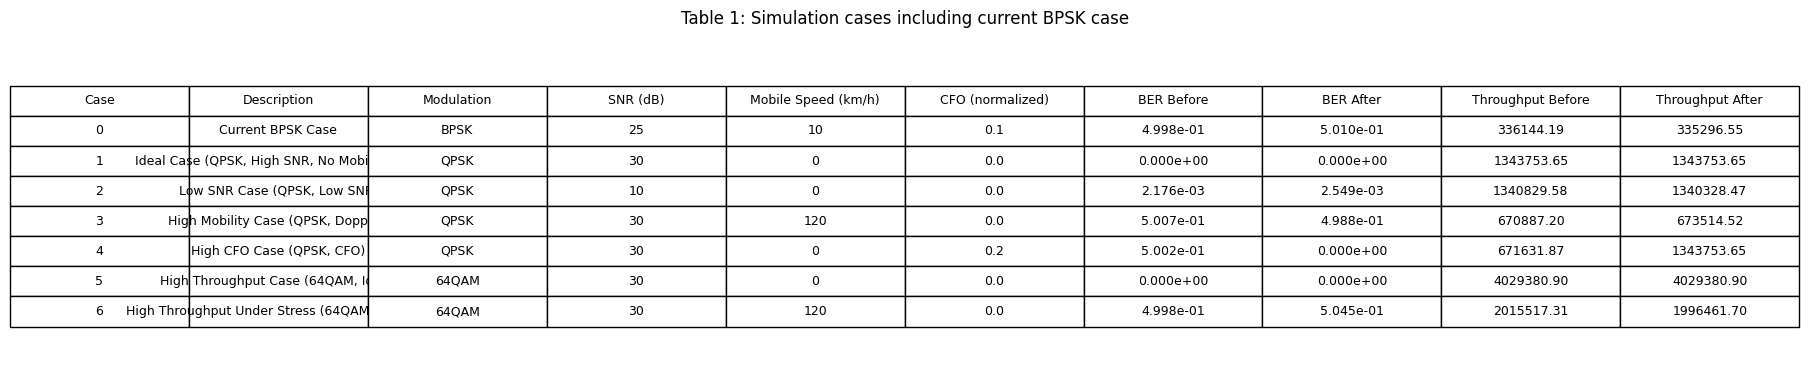

In [ ]:
# ========================================================================
# 7. PERFORMANCE ANALYSIS & REPORTING
# ========================================================================
#  Calculate and display the final performance metrics.


# -- Throughput Calculation --

ofdm_symbol_duration = (n_fft + n_cpe) / sampling_rate
total_tx_time = len(x_t) / sampling_rate

throughput_uncorr = len(im_bin) * (1 - ber_uncorr) / total_tx_time
throughput_corr = len(im_bin) * (1 - ber_corr) / total_tx_time

print(f"OFDM symbol duration     : {ofdm_symbol_duration*1e6:.3f} us")
print(f"Total transmission time  : {total_tx_time*1e3:.3f} ms")
print(f"Throughput before corr.  : {throughput_uncorr:.2f} bit/s")
print(f"Throughput after corr.   : {throughput_corr:.2f} bit/s")

# -- Final Summary Table --

print("\n================ FINAL SUMMARY ================")
print(f"{'Metric':<28}{'Before CFO Corr.':>18}{'After CFO Corr.':>18}")
print("-" * 64)
print(f"{'BER':<28}{ber_uncorr:>18.6e}{ber_corr:>18.6e}")
print(f"{'Throughput (bit/s)':<28}{throughput_uncorr:>18.2f}{throughput_corr:>18.2f}")
print(f"{'Estimated CFO':<28}{'N/A':>18}{cfo_est:>18.6f}")
print(f"{'True CFO':<28}{'N/A':>18}{cfo_normalized:>18.6f}")
print("=" * 64)


# ========================================================================
# 8. RUN ALL TABLE CASES
# ========================================================================

def run_case(case_mod_method, case_snr, case_mobile_speed, case_cfo_normalized, case_desc):
    # -----------------------------
    # Parameters derived from case
    # -----------------------------
    case_sampling_rate = n_fft * subcarrier_spacing
    case_speed_ms = case_mobile_speed * 1000 / 3600
    case_max_doppler_shift = (case_speed_ms / c) * carrier_freq

    # -----------------------------
    # Bitstream and modulation
    # -----------------------------
    if case_mod_method not in mod_methods:
        raise ValueError(f"Unsupported modulation method: {case_mod_method}")

    case_mod_order = mod_methods.index(case_mod_method) + 1
    case_zero_bits = (-len(im_bin)) % case_mod_order
    case_padded = np.hstack([im_bin, np.zeros(case_zero_bits, dtype=np.uint8)])

    case_groups = case_padded.reshape(-1, case_mod_order)
    case_weights = (2 ** np.arange(case_mod_order - 1, -1, -1)).astype(np.uint8)
    case_sym_idx = case_groups.dot(case_weights).astype(int)

    case_sym_map = symbol_book(case_mod_method)
    case_modulated_symbols = case_sym_map[case_sym_idx]

    # -----------------------------
    # Preamble generation
    # -----------------------------
    case_rand = np.random.default_rng(seed=67)

    case_preamble_freq = np.zeros(n_fft, dtype=np.complex64)
    case_active_preamble_idx = np.arange(0, n_fft, 2)
    case_preamble_freq[case_active_preamble_idx] = case_rand.choice(
        case_sym_map, size=len(case_active_preamble_idx)
    )

    case_preamble = np.fft.ifft(case_preamble_freq).astype(np.complex64)
    case_preamble = case_preamble / np.sqrt(np.mean(np.abs(case_preamble) ** 2))
    case_preamble_freq = np.fft.fft(case_preamble)
    case_preamble_cp = np.hstack([case_preamble[-n_cpe:], case_preamble]).astype(np.complex64)

    # -----------------------------
    # OFDM symbol generation
    # -----------------------------
    case_pilot_idx = np.arange(0, n_fft, pilot_spacing)
    case_data_idx = np.setdiff1d(np.arange(n_fft), case_pilot_idx)
    case_num_data_subcarriers = len(case_data_idx)

    case_pad = (-len(case_modulated_symbols)) % case_num_data_subcarriers
    case_modulated_syms_padded = np.hstack(
        [case_modulated_symbols, np.zeros(case_pad, dtype=np.complex64)]
    )
    case_num_ofdm_syms = len(case_modulated_syms_padded) // case_num_data_subcarriers

    case_data_matrix = case_modulated_syms_padded.reshape(
        case_num_ofdm_syms, case_num_data_subcarriers
    )
    case_ofdm_matrix = np.zeros((case_num_ofdm_syms, n_fft), dtype=np.complex64)
    case_ofdm_matrix[:, case_pilot_idx] = pilot_val
    case_ofdm_matrix[:, case_data_idx] = case_data_matrix

    case_ofdm_time = np.fft.ifft(case_ofdm_matrix, axis=1)
    case_ofdm_time_cp = np.hstack([case_ofdm_time[:, -n_cpe:], case_ofdm_time]).reshape(-1).astype(np.complex64)
    case_x_t = np.hstack([case_preamble_cp, case_ofdm_time_cp]).astype(np.complex64)

    # -----------------------------
    # Channel simulation
    # -----------------------------
    case_num_samples = len(case_x_t)
    case_y = np.zeros(case_num_samples, dtype=np.complex64)

    case_sample_delays = np.round(path_delays_s * case_sampling_rate).astype(int)
    case_tap_gains_lin = 10 ** (avg_path_gains_db / 20.0)

    for case_gain, case_delay in zip(case_tap_gains_lin, case_sample_delays):
        case_delayed = np.zeros(case_num_samples, dtype=np.complex64)
        if case_delay < case_num_samples:
            case_delayed[case_delay:] = case_x_t[:case_num_samples - case_delay]

        case_h_t = case_gain * jakes_fading(case_num_samples, case_max_doppler_shift, case_sampling_rate)
        case_y += case_h_t * case_delayed

    case_P_signal = np.mean(np.abs(case_y) ** 2)
    case_P_noise = case_P_signal / (10 ** (case_snr / 10))
    case_noise = np.sqrt(case_P_noise / 2) * (
        np.random.randn(case_num_samples) + 1j * np.random.randn(case_num_samples)
    ).astype(np.complex64)
    case_y += case_noise

    case_n = np.arange(case_num_samples)
    case_y_rx = case_y * np.exp(
        1j * 2 * np.pi * case_cfo_normalized * case_n / n_fft
    ).astype(np.complex64)

    # -----------------------------
    # Receiver: coarse CFO estimate
    # -----------------------------
    case_rx_preamble_cp = case_y_rx[:n_fft + n_cpe]
    case_rx_preamble = case_rx_preamble_cp[n_cpe:]
    case_first_half = case_rx_preamble[:n_fft // 2]
    case_second_half = case_rx_preamble[n_fft // 2:]
    case_S = np.sum(np.conjugate(case_first_half) * case_second_half)
    case_cfo_est = np.angle(case_S) / np.pi

    # -----------------------------
    # Correct CFO
    # -----------------------------
    case_n = np.arange(len(case_y_rx))
    if np.abs(case_cfo_est) > 1e-6:
        case_y_rx_corr = case_y_rx * np.exp(-1j * 2 * np.pi * case_cfo_est * case_n / n_fft)
    else:
        case_y_rx_corr = case_y_rx.copy()

    case_y_rx_uncorr = case_y_rx.copy()

    # -----------------------------
    # OFDM demodulation
    # -----------------------------
    case_payload_corr = case_y_rx_corr[len(case_preamble_cp):]
    case_payload_uncorr = case_y_rx_uncorr[len(case_preamble_cp):]

    case_rx_blocks_corr = case_payload_corr.reshape(case_num_ofdm_syms, n_fft + n_cpe)
    case_rx_blocks_uncorr = case_payload_uncorr.reshape(case_num_ofdm_syms, n_fft + n_cpe)

    case_rx_fd_corr = np.fft.fft(case_rx_blocks_corr[:, n_cpe:], axis=1)
    case_rx_fd_uncorr = np.fft.fft(case_rx_blocks_uncorr[:, n_cpe:], axis=1)

    # -----------------------------
    # Channel estimation
    # -----------------------------
    case_rx_preamble_corr_cp = case_y_rx_corr[: n_cpe + n_fft]
    case_rx_preamble_corr = case_rx_preamble_corr_cp[n_cpe:]
    case_Y_pre = np.fft.fft(case_rx_preamble_corr)
    case_eps = 1e-12

    case_H_est = np.zeros_like(case_Y_pre, dtype=np.complex64)
    case_H_est[case_active_preamble_idx] = (
        case_Y_pre[case_active_preamble_idx]
        / (case_preamble_freq[case_active_preamble_idx] + case_eps)
    )

    case_all_idx = np.arange(n_fft)
    case_H_real = np.interp(
        case_all_idx,
        case_active_preamble_idx,
        case_H_est[case_active_preamble_idx].real
    )
    case_H_imag = np.interp(
        case_all_idx,
        case_active_preamble_idx,
        case_H_est[case_active_preamble_idx].imag
    )
    case_H_est = (case_H_real + 1j * case_H_imag).astype(np.complex64)

    case_rx_eq_corr = case_rx_fd_corr / (case_H_est[None, :] + case_eps)
    case_rx_eq_uncorr = case_rx_fd_uncorr / (case_H_est[None, :] + case_eps)

    # -----------------------------
    # Fine phase correction using pilots
    # -----------------------------
    case_pilot_rx_corr = case_rx_eq_corr[:, case_pilot_idx]
    case_pilot_phase_corr = np.angle(np.mean(case_pilot_rx_corr / pilot_val, axis=1))
    case_rx_eq_corr_phase = case_rx_eq_corr * np.exp(-1j * case_pilot_phase_corr[:, None])

    case_rx_data_corr = case_rx_eq_corr_phase[:, case_data_idx].ravel()[: len(case_modulated_symbols)]
    case_rx_data_uncorr = case_rx_eq_uncorr[:, case_data_idx].ravel()[: len(case_modulated_symbols)]

    # -----------------------------
    # Detection
    # -----------------------------
    case_tree = cKDTree(np.column_stack([case_sym_map.real, case_sym_map.imag]))

    _, case_det_idx_corr = case_tree.query(
        np.column_stack([case_rx_data_corr.real, case_rx_data_corr.imag]), k=1
    )
    _, case_det_idx_uncorr = case_tree.query(
        np.column_stack([case_rx_data_uncorr.real, case_rx_data_uncorr.imag]), k=1
    )

    case_rx_bits_corr = ints_to_bits(case_det_idx_corr, case_mod_order)[: len(im_bin)]
    case_rx_bits_uncorr = ints_to_bits(case_det_idx_uncorr, case_mod_order)[: len(im_bin)]

    case_ber_corr = np.mean(case_rx_bits_corr != im_bin)
    case_ber_uncorr = np.mean(case_rx_bits_uncorr != im_bin)

    # -----------------------------
    # Throughput
    # -----------------------------
    case_total_tx_time = len(case_x_t) / case_sampling_rate
    case_throughput_uncorr = len(im_bin) * (1 - case_ber_uncorr) / case_total_tx_time
    case_throughput_corr = len(im_bin) * (1 - case_ber_corr) / case_total_tx_time

    return {
        "Description": case_desc,
        "Modulation": case_mod_method,
        "SNR (dB)": case_snr,
        "Mobile Speed (km/h)": case_mobile_speed,
        "CFO (normalized)": case_cfo_normalized,
        "Estimated CFO": case_cfo_est,
        "BER Before CFO Corr.": case_ber_uncorr,
        "BER After CFO Corr.": case_ber_corr,
        "Throughput Before (bit/s)": case_throughput_uncorr,
        "Throughput After (bit/s)": case_throughput_corr,
    }


cases_to_run = [
    {"Case": 0, "Description": "Current BPSK Case", "Modulation": "BPSK", "SNR (dB)": 25, "Mobile Speed (km/h)": 10, "CFO (normalized)": 0.1},
    {"Case": 1, "Description": "Ideal Case (QPSK, High SNR, No Mobility/CFO)", "Modulation": "QPSK", "SNR (dB)": 30, "Mobile Speed (km/h)": 0, "CFO (normalized)": 0.0},
    {"Case": 2, "Description": "Low SNR Case (QPSK, Low SNR)", "Modulation": "QPSK", "SNR (dB)": 10, "Mobile Speed (km/h)": 0, "CFO (normalized)": 0.0},
    {"Case": 3, "Description": "High Mobility Case (QPSK, Doppler)", "Modulation": "QPSK", "SNR (dB)": 30, "Mobile Speed (km/h)": 120, "CFO (normalized)": 0.0},
    {"Case": 4, "Description": "High CFO Case (QPSK, CFO)", "Modulation": "QPSK", "SNR (dB)": 30, "Mobile Speed (km/h)": 0, "CFO (normalized)": 0.2},
    {"Case": 5, "Description": "High Throughput Case (64QAM, Ideal)", "Modulation": "64QAM", "SNR (dB)": 30, "Mobile Speed (km/h)": 0, "CFO (normalized)": 0.0},
    {"Case": 6, "Description": "High Throughput Under Stress (64QAM, Doppler)", "Modulation": "64QAM", "SNR (dB)": 30, "Mobile Speed (km/h)": 120, "CFO (normalized)": 0.0},
]

simulation_cases = []
for case in cases_to_run:
    print(f"\nRunning Case {case['Case']}: {case['Description']}")
    result = run_case(
        case["Modulation"],
        case["SNR (dB)"],
        case["Mobile Speed (km/h)"],
        case["CFO (normalized)"],
        case["Description"],
    )
    result["Case"] = case["Case"]
    simulation_cases.append(result)

print("\n================ SIMULATION CASES TABLE ================")
header = (
    f"{'Case':<6}"
    f"{'Description':<52}"
    f"{'Mod':<10}"
    f"{'SNR':<8}"
    f"{'Speed':<12}"
    f"{'CFO':<10}"
    f"{'BER Before':<15}"
    f"{'BER After':<15}"
    f"{'Thr Before':<15}"
    f"{'Thr After':<15}"
)
print(header)
print("-" * len(header))

for row in simulation_cases:
    ber_b = f"{row['BER Before CFO Corr.']:.3e}"
    ber_a = f"{row['BER After CFO Corr.']:.3e}"
    thr_b = f"{row['Throughput Before (bit/s)']:.2f}"
    thr_a = f"{row['Throughput After (bit/s)']:.2f}"

    print(
        f"{row['Case']:<6}"
        f"{row['Description']:<52.52}"
        f"{row['Modulation']:<10}"
        f"{row['SNR (dB)']:<8}"
        f"{row['Mobile Speed (km/h)']:<12}"
        f"{row['CFO (normalized)']:<10}"
        f"{ber_b:<15}"
        f"{ber_a:<15}"
        f"{thr_b:<15}"
        f"{thr_a:<15}"
    )

fig, ax = plt.subplots(figsize=(18, 4))
ax.axis("off")

table_rows = []
for row in simulation_cases:
    table_rows.append([
        row["Case"],
        row["Description"],
        row["Modulation"],
        row["SNR (dB)"],
        row["Mobile Speed (km/h)"],
        row["CFO (normalized)"],
        f"{row['BER Before CFO Corr.']:.3e}",
        f"{row['BER After CFO Corr.']:.3e}",
        f"{row['Throughput Before (bit/s)']:.2f}",
        f"{row['Throughput After (bit/s)']:.2f}",
    ])

col_labels = [
    "Case",
    "Description",
    "Modulation",
    "SNR (dB)",
    "Mobile Speed (km/h)",
    "CFO (normalized)",
    "BER Before",
    "BER After",
    "Throughput Before",
    "Throughput After",
]

tbl = ax.table(
    cellText=table_rows,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)

plt.title("Table 1: Simulation cases including current BPSK case")
plt.tight_layout()
plt.show()


Running Case 0: Current BPSK Case

Running Case 1: Ideal Case (QPSK, High SNR, No Mobility/CFO)

Running Case 2: Low SNR Case (QPSK, Low SNR)

Running Case 3: High Mobility Case (QPSK, Doppler)

Running Case 4: High CFO Case (QPSK, CFO)

Running Case 5: High Throughput Case (64QAM, Ideal)

Running Case 6: High Throughput Under Stress (64QAM, Doppler)

================ SIMULATION CASES TABLE ================
Case  Description                                         Mod       SNR     Speed       CFO       BER Before     BER After      Thr Before     Thr After      
--------------------------------------------------------------------------------------------------------------------------------------------------------------
0     Current BPSK Case                                   BPSK      25      10          0.1       4.994e-01      4.979e-01      336363.98      337419.51      
1     Ideal Case (QPSK, High SNR, No Mobility/CFO)        QPSK      30      0           0.0       0.000e+00    

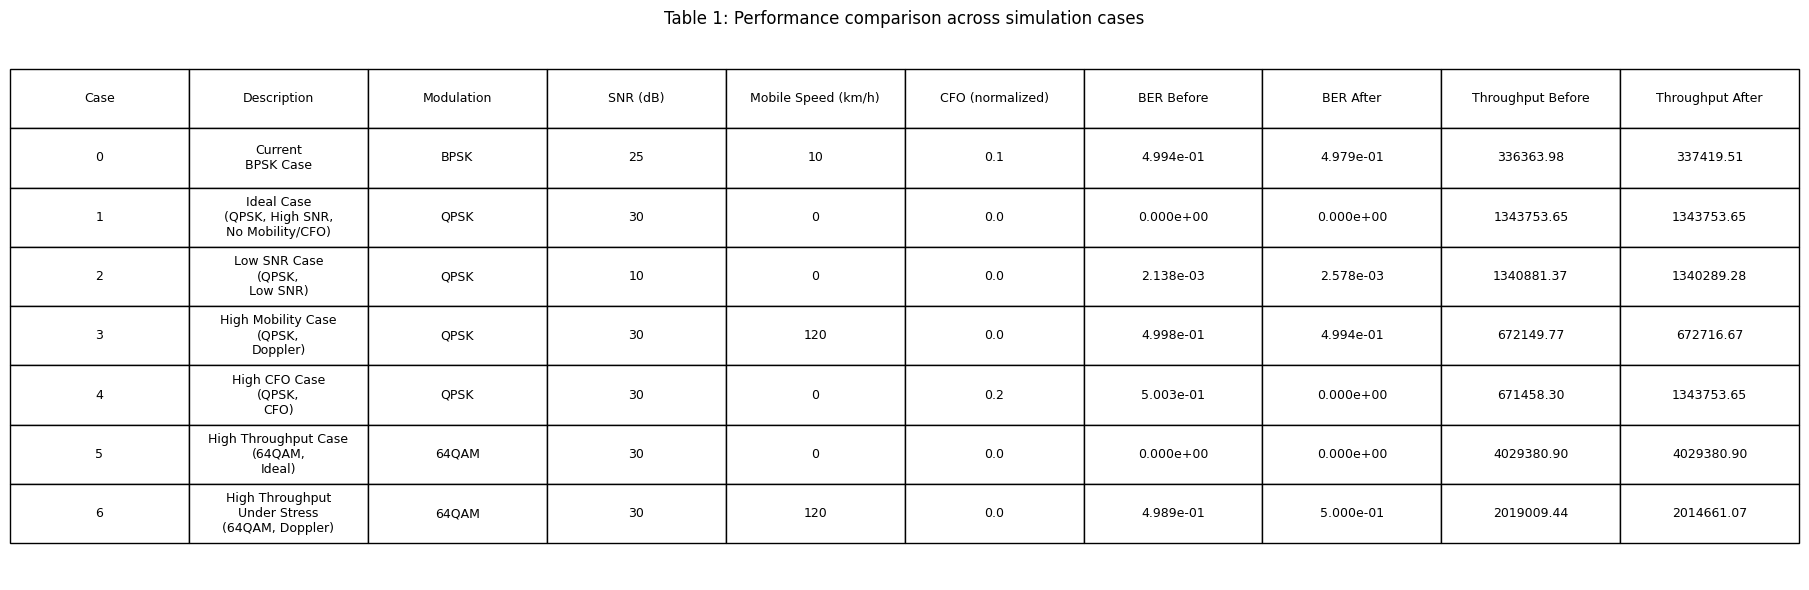

In [ ]:
# ========================================================================
# 8. RUN ALL TABLE CASES
# ========================================================================

def run_case(case_mod_method, case_snr, case_mobile_speed, case_cfo_normalized, case_desc):
    # -----------------------------
    # Parameters derived from case
    # -----------------------------
    case_sampling_rate = n_fft * subcarrier_spacing
    case_speed_ms = case_mobile_speed * 1000 / 3600
    case_max_doppler_shift = (case_speed_ms / c) * carrier_freq

    # -----------------------------
    # Bitstream and modulation
    # -----------------------------
    if case_mod_method not in mod_methods:
        raise ValueError(f"Unsupported modulation method: {case_mod_method}")

    case_mod_order = mod_methods.index(case_mod_method) + 1
    case_zero_bits = (-len(im_bin)) % case_mod_order
    case_padded = np.hstack([im_bin, np.zeros(case_zero_bits, dtype=np.uint8)])

    case_groups = case_padded.reshape(-1, case_mod_order)
    case_weights = (2 ** np.arange(case_mod_order - 1, -1, -1)).astype(np.uint8)
    case_sym_idx = case_groups.dot(case_weights).astype(int)

    case_sym_map = symbol_book(case_mod_method)
    case_modulated_symbols = case_sym_map[case_sym_idx]

    # -----------------------------
    # Preamble generation
    # -----------------------------
    case_rand = np.random.default_rng(seed=67)

    case_preamble_freq = np.zeros(n_fft, dtype=np.complex64)
    case_active_preamble_idx = np.arange(0, n_fft, 2)
    case_preamble_freq[case_active_preamble_idx] = case_rand.choice(
        case_sym_map, size=len(case_active_preamble_idx)
    )

    case_preamble = np.fft.ifft(case_preamble_freq).astype(np.complex64)
    case_preamble = case_preamble / np.sqrt(np.mean(np.abs(case_preamble) ** 2))
    case_preamble_freq = np.fft.fft(case_preamble)
    case_preamble_cp = np.hstack([case_preamble[-n_cpe:], case_preamble]).astype(np.complex64)

    # -----------------------------
    # OFDM symbol generation
    # -----------------------------
    case_pilot_idx = np.arange(0, n_fft, pilot_spacing)
    case_data_idx = np.setdiff1d(np.arange(n_fft), case_pilot_idx)
    case_num_data_subcarriers = len(case_data_idx)

    case_pad = (-len(case_modulated_symbols)) % case_num_data_subcarriers
    case_modulated_syms_padded = np.hstack(
        [case_modulated_symbols, np.zeros(case_pad, dtype=np.complex64)]
    )
    case_num_ofdm_syms = len(case_modulated_syms_padded) // case_num_data_subcarriers

    case_data_matrix = case_modulated_syms_padded.reshape(
        case_num_ofdm_syms, case_num_data_subcarriers
    )
    case_ofdm_matrix = np.zeros((case_num_ofdm_syms, n_fft), dtype=np.complex64)
    case_ofdm_matrix[:, case_pilot_idx] = pilot_val
    case_ofdm_matrix[:, case_data_idx] = case_data_matrix

    case_ofdm_time = np.fft.ifft(case_ofdm_matrix, axis=1)
    case_ofdm_time_cp = np.hstack([case_ofdm_time[:, -n_cpe:], case_ofdm_time]).reshape(-1).astype(np.complex64)
    case_x_t = np.hstack([case_preamble_cp, case_ofdm_time_cp]).astype(np.complex64)

    # -----------------------------
    # Channel simulation
    # -----------------------------
    case_num_samples = len(case_x_t)
    case_y = np.zeros(case_num_samples, dtype=np.complex64)

    case_sample_delays = np.round(path_delays_s * case_sampling_rate).astype(int)
    case_tap_gains_lin = 10 ** (avg_path_gains_db / 20.0)

    for case_gain, case_delay in zip(case_tap_gains_lin, case_sample_delays):
        case_delayed = np.zeros(case_num_samples, dtype=np.complex64)
        if case_delay < case_num_samples:
            case_delayed[case_delay:] = case_x_t[:case_num_samples - case_delay]

        case_h_t = case_gain * jakes_fading(case_num_samples, case_max_doppler_shift, case_sampling_rate)
        case_y += case_h_t * case_delayed

    case_P_signal = np.mean(np.abs(case_y) ** 2)
    case_P_noise = case_P_signal / (10 ** (case_snr / 10))
    case_noise = np.sqrt(case_P_noise / 2) * (
        np.random.randn(case_num_samples) + 1j * np.random.randn(case_num_samples)
    ).astype(np.complex64)
    case_y += case_noise

    case_n = np.arange(case_num_samples)
    case_y_rx = case_y * np.exp(
        1j * 2 * np.pi * case_cfo_normalized * case_n / n_fft
    ).astype(np.complex64)

    # -----------------------------
    # Receiver: coarse CFO estimate
    # -----------------------------
    case_rx_preamble_cp = case_y_rx[:n_fft + n_cpe]
    case_rx_preamble = case_rx_preamble_cp[n_cpe:]
    case_first_half = case_rx_preamble[:n_fft // 2]
    case_second_half = case_rx_preamble[n_fft // 2:]
    case_S = np.sum(np.conjugate(case_first_half) * case_second_half)
    case_cfo_est = np.angle(case_S) / np.pi

    # -----------------------------
    # Correct CFO
    # -----------------------------
    case_n = np.arange(len(case_y_rx))
    if np.abs(case_cfo_est) > 1e-6:
        case_y_rx_corr = case_y_rx * np.exp(-1j * 2 * np.pi * case_cfo_est * case_n / n_fft)
    else:
        case_y_rx_corr = case_y_rx.copy()

    case_y_rx_uncorr = case_y_rx.copy()

    # -----------------------------
    # OFDM demodulation
    # -----------------------------
    case_payload_corr = case_y_rx_corr[len(case_preamble_cp):]
    case_payload_uncorr = case_y_rx_uncorr[len(case_preamble_cp):]

    case_rx_blocks_corr = case_payload_corr.reshape(case_num_ofdm_syms, n_fft + n_cpe)
    case_rx_blocks_uncorr = case_payload_uncorr.reshape(case_num_ofdm_syms, n_fft + n_cpe)

    case_rx_fd_corr = np.fft.fft(case_rx_blocks_corr[:, n_cpe:], axis=1)
    case_rx_fd_uncorr = np.fft.fft(case_rx_blocks_uncorr[:, n_cpe:], axis=1)

    # -----------------------------
    # Channel estimation
    # -----------------------------
    case_rx_preamble_corr_cp = case_y_rx_corr[: n_cpe + n_fft]
    case_rx_preamble_corr = case_rx_preamble_corr_cp[n_cpe:]
    case_Y_pre = np.fft.fft(case_rx_preamble_corr)
    case_eps = 1e-12

    case_H_est = np.zeros_like(case_Y_pre, dtype=np.complex64)
    case_H_est[case_active_preamble_idx] = (
        case_Y_pre[case_active_preamble_idx]
        / (case_preamble_freq[case_active_preamble_idx] + case_eps)
    )

    case_all_idx = np.arange(n_fft)
    case_H_real = np.interp(
        case_all_idx,
        case_active_preamble_idx,
        case_H_est[case_active_preamble_idx].real
    )
    case_H_imag = np.interp(
        case_all_idx,
        case_active_preamble_idx,
        case_H_est[case_active_preamble_idx].imag
    )
    case_H_est = (case_H_real + 1j * case_H_imag).astype(np.complex64)

    case_rx_eq_corr = case_rx_fd_corr / (case_H_est[None, :] + case_eps)
    case_rx_eq_uncorr = case_rx_fd_uncorr / (case_H_est[None, :] + case_eps)

    # -----------------------------
    # Fine phase correction using pilots
    # -----------------------------
    case_pilot_rx_corr = case_rx_eq_corr[:, case_pilot_idx]
    case_pilot_phase_corr = np.angle(np.mean(case_pilot_rx_corr / pilot_val, axis=1))
    case_rx_eq_corr_phase = case_rx_eq_corr * np.exp(-1j * case_pilot_phase_corr[:, None])

    case_rx_data_corr = case_rx_eq_corr_phase[:, case_data_idx].ravel()[: len(case_modulated_symbols)]
    case_rx_data_uncorr = case_rx_eq_uncorr[:, case_data_idx].ravel()[: len(case_modulated_symbols)]

    # -----------------------------
    # Detection
    # -----------------------------
    case_tree = cKDTree(np.column_stack([case_sym_map.real, case_sym_map.imag]))

    _, case_det_idx_corr = case_tree.query(
        np.column_stack([case_rx_data_corr.real, case_rx_data_corr.imag]), k=1
    )
    _, case_det_idx_uncorr = case_tree.query(
        np.column_stack([case_rx_data_uncorr.real, case_rx_data_uncorr.imag]), k=1
    )

    case_rx_bits_corr = ints_to_bits(case_det_idx_corr, case_mod_order)[: len(im_bin)]
    case_rx_bits_uncorr = ints_to_bits(case_det_idx_uncorr, case_mod_order)[: len(im_bin)]

    case_ber_corr = np.mean(case_rx_bits_corr != im_bin)
    case_ber_uncorr = np.mean(case_rx_bits_uncorr != im_bin)

    # -----------------------------
    # Throughput
    # -----------------------------
    case_total_tx_time = len(case_x_t) / case_sampling_rate
    case_throughput_uncorr = len(im_bin) * (1 - case_ber_uncorr) / case_total_tx_time
    case_throughput_corr = len(im_bin) * (1 - case_ber_corr) / case_total_tx_time

    return {
        "Description": case_desc,
        "Modulation": case_mod_method,
        "SNR (dB)": case_snr,
        "Mobile Speed (km/h)": case_mobile_speed,
        "CFO (normalized)": case_cfo_normalized,
        "Estimated CFO": case_cfo_est,
        "BER Before CFO Corr.": case_ber_uncorr,
        "BER After CFO Corr.": case_ber_corr,
        "Throughput Before (bit/s)": case_throughput_uncorr,
        "Throughput After (bit/s)": case_throughput_corr,
    }


cases_to_run = [
    {"Case": 0, "Description": "Current\nBPSK Case", "Modulation": "BPSK", "SNR (dB)": 25, "Mobile Speed (km/h)": 10, "CFO (normalized)": 0.1},
    {"Case": 1, "Description": "Ideal Case\n(QPSK, High SNR,\nNo Mobility/CFO)", "Modulation": "QPSK", "SNR (dB)": 30, "Mobile Speed (km/h)": 0, "CFO (normalized)": 0.0},
    {"Case": 2, "Description": "Low SNR Case\n(QPSK,\nLow SNR)", "Modulation": "QPSK", "SNR (dB)": 10, "Mobile Speed (km/h)": 0, "CFO (normalized)": 0.0},
    {"Case": 3, "Description": "High Mobility Case\n(QPSK,\nDoppler)", "Modulation": "QPSK", "SNR (dB)": 30, "Mobile Speed (km/h)": 120, "CFO (normalized)": 0.0},
    {"Case": 4, "Description": "High CFO Case\n(QPSK,\nCFO)", "Modulation": "QPSK", "SNR (dB)": 30, "Mobile Speed (km/h)": 0, "CFO (normalized)": 0.2},
    {"Case": 5, "Description": "High Throughput Case\n(64QAM,\nIdeal)", "Modulation": "64QAM", "SNR (dB)": 30, "Mobile Speed (km/h)": 0, "CFO (normalized)": 0.0},
    {"Case": 6, "Description": "High Throughput\nUnder Stress\n(64QAM, Doppler)", "Modulation": "64QAM", "SNR (dB)": 30, "Mobile Speed (km/h)": 120, "CFO (normalized)": 0.0},
]

simulation_cases = []
for case in cases_to_run:
    print(f"\nRunning Case {case['Case']}: {case['Description'].replace(chr(10), ' ')}")
    result = run_case(
        case["Modulation"],
        case["SNR (dB)"],
        case["Mobile Speed (km/h)"],
        case["CFO (normalized)"],
        case["Description"],
    )
    result["Case"] = case["Case"]
    simulation_cases.append(result)

print("\n================ SIMULATION CASES TABLE ================")
header = (
    f"{'Case':<6}"
    f"{'Description':<52}"
    f"{'Mod':<10}"
    f"{'SNR':<8}"
    f"{'Speed':<12}"
    f"{'CFO':<10}"
    f"{'BER Before':<15}"
    f"{'BER After':<15}"
    f"{'Thr Before':<15}"
    f"{'Thr After':<15}"
)
print(header)
print("-" * len(header))

for row in simulation_cases:
    ber_b = f"{row['BER Before CFO Corr.']:.3e}"
    ber_a = f"{row['BER After CFO Corr.']:.3e}"
    thr_b = f"{row['Throughput Before (bit/s)']:.2f}"
    thr_a = f"{row['Throughput After (bit/s)']:.2f}"

    print(
        f"{row['Case']:<6}"
        f"{row['Description'].replace(chr(10), ' '):<52.52}"
        f"{row['Modulation']:<10}"
        f"{row['SNR (dB)']:<8}"
        f"{row['Mobile Speed (km/h)']:<12}"
        f"{row['CFO (normalized)']:<10}"
        f"{ber_b:<15}"
        f"{ber_a:<15}"
        f"{thr_b:<15}"
        f"{thr_a:<15}"
    )

fig, ax = plt.subplots(figsize=(18, 6))
ax.axis("off")

table_rows = []
for row in simulation_cases:
    table_rows.append([
        row["Case"],
        row["Description"],
        row["Modulation"],
        row["SNR (dB)"],
        row["Mobile Speed (km/h)"],
        row["CFO (normalized)"],
        f"{row['BER Before CFO Corr.']:.3e}",
        f"{row['BER After CFO Corr.']:.3e}",
        f"{row['Throughput Before (bit/s)']:.2f}",
        f"{row['Throughput After (bit/s)']:.2f}",
    ])

col_labels = [
    "Case",
    "Description",
    "Modulation",
    "SNR (dB)",
    "Mobile Speed (km/h)",
    "CFO (normalized)",
    "BER Before",
    "BER After",
    "Throughput Before",
    "Throughput After",
]

tbl = ax.table(
    cellText=table_rows,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 3.0)

for (r, c), cell in tbl.get_celld().items():
    cell.set_text_props(va="center")
    if r == 0:
        cell.set_text_props(weight="normal")

plt.title("Table 1: Performance comparison across simulation cases")
plt.tight_layout()
plt.show()

Max Doppler Shift: 19.44 Hz
Image is loaded
True CFO: 0.1000, Estimated CFO: 0.0988
BER before CFO correction : 0.500409
BER after CFO correction  : 0.001719


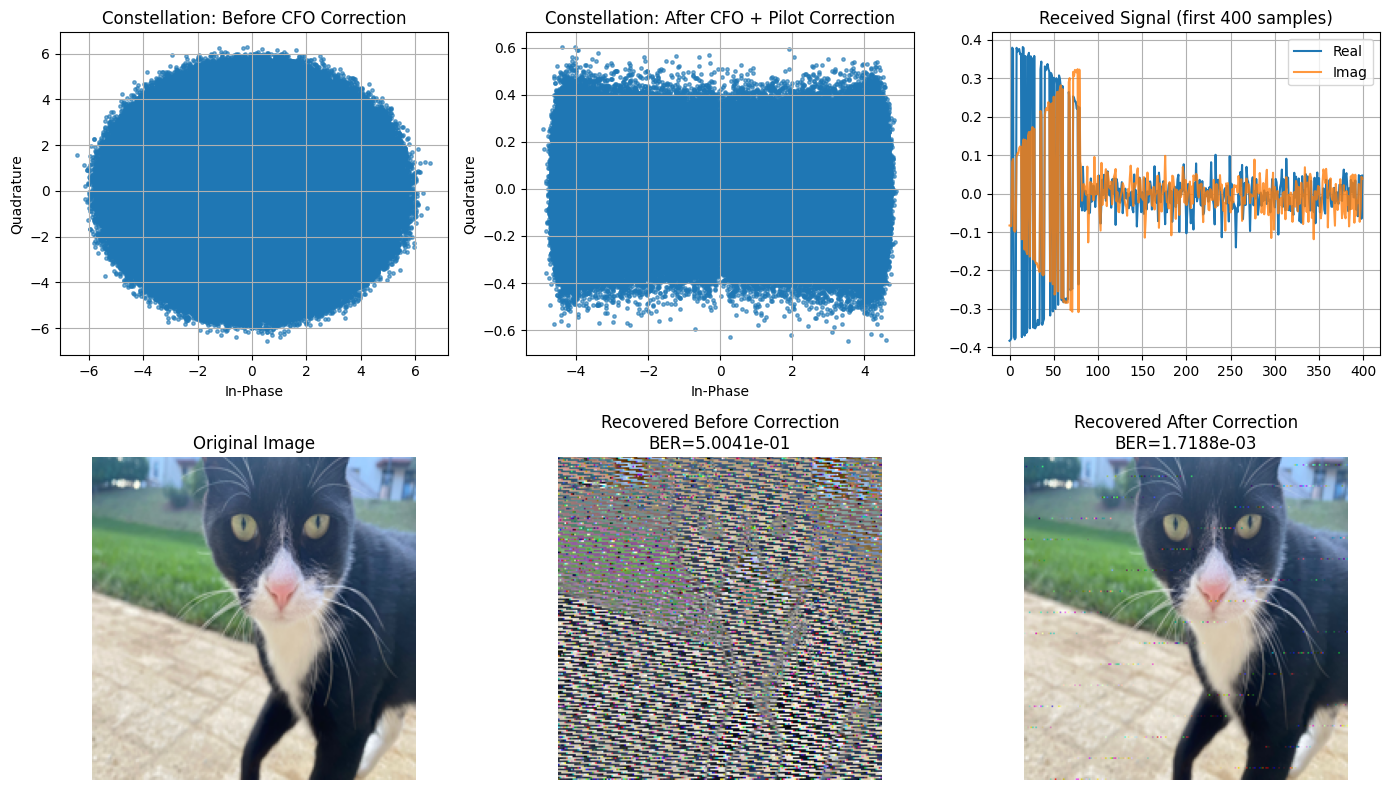

Sample delays: [0 0 0]
Near-zero preamble bins: 32


In [ ]:
# ========================================================================
# 1. SIMULATION PARAMETERS
# ========================================================================

# -- OFDM Parameters --
mod_method = "BPSK"      # Modulation scheme example.
n_fft = 64               # FFT size, representing the number of subcarriers per OFDM symbol.
n_cpe = 16               # Cyclic Prefix length, protects against Inter-Symbol Interference (ISI).

# -- Channel --
snr = 25  # Signal-to-Noise Ratio in dB. This is not default.

# -- 5G & Doppler Physical Parameters --
subcarrier_spacing = 15e3  # Subcarrier spacing in Hz (e.g., 15 kHz for a 5G NR-like system).
sampling_rate = n_fft * subcarrier_spacing  # The required sample rate of the system.
carrier_freq = 2.1e9  # Carrier frequency in Hz (e.g., 2.1 GHz).
mobile_speed = 10    # Speed of the receiver in km/h.

# Calculate the maximum Doppler shift based on the physical parameters.
c = 3e8  # Speed of light in m/s.
speed_ms = mobile_speed * 1000 / 3600  # Convert speed to m/s.
max_doppler_shift = (speed_ms / c) * carrier_freq
print(f"Max Doppler Shift: {max_doppler_shift:.2f} Hz")

# -- CFO Parameter --
# Normalized Carrier Frequency Offset. This simulates the frequency
# mismatch between the transmitter and receiver's local oscillators.
cfo_normalized = 0.1

# -- Pilot Parameters --
# Pilots are known symbols inserted into the data stream to help the receiver
# track phase changes and other channel variations.
pilot_spacing = 8        # Insert a pilot on every 8th subcarrier.
pilot_val = 1 + 1j       # The fixed complex value of the pilot symbols.

# A list of supported modulation methods.
mod_methods = ["BPSK", "QPSK", "8PSK", "16QAM", "32QAM", "64QAM"]



# ========================================================================
# 2. TRANSMITTER: DATA PREPARATION & MODULATION
# ========================================================================

# -- Source Data to Binary Stream --
# Load an image to use as the data source.
im_full = np.array(Image.open("cat.jpeg"))
im = np.array(
    Image.fromarray(im_full).resize((200, 200), resample=Image.BICUBIC)
)
print("Image is loaded")

# Convert the 8-bit pixel values (0-255) into a stream of binary characters.
im_bin = np.unpackbits(im.astype(np.uint8).ravel(), bitorder="big").astype(np.uint8)


# -- Binary Stream to Integer Symbols --
# Calculate how many zeros we need to add to make the bit stream length a
# multiple of the modulation order. This is called padding.
if mod_method not in mod_methods:
    raise ValueError(f"Unsupported modulation method: {mod_method}")

mod_order=mod_methods.index(mod_method)+1
zero_bits= -len(im_bin) % mod_order
padded= np.hstack([im_bin,np.zeros(zero_bits,dtype=np.uint8)])

groups= padded.reshape(-1, mod_order)
weights= (2**np.arange(mod_order-1, -1, -1)).astype(np.uint8)
sym_idx= groups.dot(weights).astype(int)
# -- Symbol Modulation --
def symbol_book(mod_method):
    if mod_method == "BPSK":
        const = np.array([-1+0j, 1+0j], dtype=np.complex64)

    elif mod_method == "QPSK":
        const = np.array([1+1j, -1+1j, -1-1j, 1-1j], dtype=np.complex64)

    elif mod_method == "8PSK":
        rot = np.exp(1j * 2 * np.pi / 8)
        const = np.power(rot, np.arange(8)).astype(np.complex64)

    elif mod_method == "16QAM":
        nums = np.array([-3, -1, 1, 3], dtype=np.float32)
        const = np.array([i + 1j*q for i in nums for q in nums], dtype=np.complex64)

    elif mod_method == "32QAM":
        # Simple rectangular 32-QAM: 8 x 4 = 32 points
        real_nums = np.array([-7, -5, -3, -1, 1, 3, 5, 7], dtype=np.float32)
        im_nums = np.array([-3, -1, 1, 3], dtype=np.float32)
        const = np.array([a + 1j*b for a in real_nums for b in im_nums], dtype=np.complex64)

    elif mod_method == "64QAM":
        nums = np.array([-7, -5, -3, -1, 1, 3, 5, 7], dtype=np.float32)
        const = np.array([a + 1j*b for a in nums for b in nums], dtype=np.complex64)

    else:
        raise ValueError(f"Unsupported modulation method: {mod_method}")

    # Normalising average power to 1
    const = const / np.sqrt(np.mean(np.abs(const) ** 2))
    return const

sym_map = symbol_book(mod_method)
modulated_symbols = sym_map[sym_idx]

# ========================================================================
# 3. TRANSMITTER: OFDM SYMBOL GENERATION
# ========================================================================


# -- Preamble Generation  --
# Generate a preamble. Example: Schmidl & Cox.
rand= np.random.default_rng(seed=67)
half_preamble= rand.choice(sym_map, size=n_fft//2)
preamble= np.hstack([half_preamble, half_preamble]).astype(np.complex64)
preamble= preamble / np.sqrt(np.mean(np.abs(preamble)**2))

preamble_freq= np.fft.fft(preamble)
preamble_cp= np.hstack([preamble[-n_cpe:], preamble]).astype(np.complex64)

#Pilot
pilot_idx= np.arange(0,n_fft,pilot_spacing)
data_idx= np.setdiff1d(np.arange(n_fft), pilot_idx)
num_data_subcarriers= len(data_idx)
pad= -len(modulated_symbols)% num_data_subcarriers
modulated_syms_padded= np.hstack([modulated_symbols, np.zeros(pad, dtype=np.complex64)])
num_ofdm_syms= len(modulated_syms_padded)// num_data_subcarriers
#arrangement of symbols into OFDM symbols
data_matrix= modulated_syms_padded.reshape(num_ofdm_syms, num_data_subcarriers)
ofdm_matrix= np.zeros((num_ofdm_syms, n_fft), dtype=np.complex64)
ofdm_matrix[:, pilot_idx]= pilot_val
ofdm_matrix[:, data_idx]= data_matrix
#IFFT and CP
ofdm_time= np.fft.ifft(ofdm_matrix, axis=1)
ofdm_time_cp= np.hstack([ofdm_time[:,-n_cpe:], ofdm_time]).reshape(-1).astype(np.complex64)
x_t= np.hstack([preamble_cp, ofdm_time_cp]).astype(np.complex64)
# ========================================================================
# 4. CHANNEL SIMULATION
# ========================================================================


# -- Time-Varying Rayleigh Fading Channel with Jakes Doppler --
# In MATLAB, it is comm.RayleighChannel

def jakes_fading(num_samples, max_doppler_shift, sampling_rate, num_sin=4):
    t = np.arange(num_samples) / sampling_rate
    phi= 2 * np.pi * np.random.rand(num_sin + 1)  # Random initial phase for each sine
    alpa= 2*np.pi* np.arange(num_sin+1) / (num_sin+1)  # Uniformly spaced angles of arrival
    fading = np.zeros(num_samples, dtype=np.complex64)
    for k in range(1, num_sin+1):
        fk = 2*np.pi* max_doppler_shift * np.cos(alpa[k])
        fading += np.exp(1j * (fk * t + phi[k]))
    fading /= np.sqrt(num_sin)
    return fading.astype(np.complex64)


path_delays_s = np.array([0.0, 0.2e-7, 0.5e-7], dtype=np.float64)
avg_path_gains_db = np.array([0.0, -3.0, -6.0], dtype=np.float64)

sample_delays = np.round(path_delays_s * sampling_rate).astype(int)
tap_gains_lin = 10 ** (avg_path_gains_db / 20.0)

num_samples=len(x_t)
y= np.zeros(num_samples,dtype=np.complex64)
for gain, delay in zip(tap_gains_lin, sample_delays):
    delayed= np.zeros(num_samples, dtype=np.complex64)
    if delay< num_samples:
        delayed[delay:]=x_t[:num_samples-delay]

    h_t= gain*jakes_fading(num_samples, max_doppler_shift, sampling_rate)
    y+= h_t* delayed

#AWGN
P_signal= np.mean(np.abs(y)**2)
P_noise= P_signal / (10**(snr/10))
noise= np.sqrt(P_noise/2)* (np.random.randn(num_samples) + 1j* np.random.randn(num_samples)).astype(np.complex64)
y+= noise

n= np.arange(num_samples)
y_rx= y* np.exp(1j* 2* np.pi* cfo_normalized* n/ n_fft).astype(np.complex64)



# ========================================================================
# 5. RECEIVER: OFDM DEMODULATION & DATA RECOVERY
# ========================================================================
def ints_to_bits(indices, bits_per_symbol):
    indices = np.asarray(indices).astype(int)
    bits = ((indices[:, None] & (1 << np.arange(bits_per_symbol - 1, -1, -1))) > 0)
    return bits.astype(np.uint8).ravel()

#Coarse CFO estimation using the preamble
#time domain   |CP + PREAMBLE | CP + OFDM1 | CP + OFDM2 | CP + OFDM3 |
rx_preamble_cp= y_rx[:n_fft+n_cpe]  #CP +preamble
rx_preamble= rx_preamble_cp[n_cpe:]  #preamble
first_half= rx_preamble[:n_fft//2]
second_half= rx_preamble[n_fft//2:]
S= np.sum(np.conjugate(first_half)* second_half)
cfo_est= np.angle(S)/np.pi
print(f"True CFO: {cfo_normalized:.4f}, Estimated CFO: {cfo_est:.4f}")

# Correct CFO
n = np.arange(len(y_rx))
if np.abs(cfo_est) > 1e-6:
    y_rx_corr = y_rx * np.exp(-1j * 2 * np.pi * cfo_est * n / n_fft)
else:
    y_rx_corr = y_rx.copy()

y_rx_uncorr = y_rx.copy()


#OFDM Demodulation
payload_corr = y_rx_corr[len(preamble_cp):]
payload_uncorr = y_rx_uncorr[len(preamble_cp):]

rx_blocks_corr = payload_corr.reshape(num_ofdm_syms, n_fft + n_cpe)
rx_blocks_uncorr = payload_uncorr.reshape(num_ofdm_syms, n_fft + n_cpe)

rx_fd_corr = np.fft.fft(rx_blocks_corr[:, n_cpe:], axis=1)
rx_fd_uncorr = np.fft.fft(rx_blocks_uncorr[:, n_cpe:], axis=1)

# Channel estimation

# Channel estimation
rx_preamble_corr_cp = y_rx_corr[: n_cpe + n_fft]
rx_preamble_corr = rx_preamble_corr_cp[n_cpe:]
Y_pre = np.fft.fft(rx_preamble_corr)
eps = 1e-12

nz = np.abs(preamble_freq) > 1e-8
H_est = np.zeros_like(Y_pre, dtype=np.complex64)
H_est[nz] = Y_pre[nz] / (preamble_freq[nz] + eps)

all_idx = np.arange(n_fft)
H_real = np.interp(all_idx, all_idx[nz], H_est[nz].real)
H_imag = np.interp(all_idx, all_idx[nz], H_est[nz].imag)
H_est = (H_real + 1j * H_imag).astype(np.complex64)


rx_eq_corr = rx_fd_corr / (H_est[None, :] + eps) #equalization
rx_eq_uncorr = rx_fd_uncorr / (H_est[None, :] + eps)

# Fine CFO correction using pilots
pilot_rx_corr = rx_eq_corr[:, pilot_idx]
pilot_phase_corr = np.angle(np.mean(pilot_rx_corr / pilot_val, axis=1))
rx_eq_corr_phase = rx_eq_corr * np.exp(-1j * pilot_phase_corr[:, None])

rx_data_corr = rx_eq_corr_phase[:, data_idx].ravel()[: len(modulated_symbols)]
rx_data_uncorr = rx_eq_uncorr[:, data_idx].ravel()[: len(modulated_symbols)]

# Nearest-neighbour symbol detection
tree = cKDTree(np.column_stack([symbol_book(mod_method).real, symbol_book(mod_method).imag]))

_, det_idx_corr = tree.query(np.column_stack([rx_data_corr.real, rx_data_corr.imag]), k=1)
_, det_idx_uncorr = tree.query(np.column_stack([rx_data_uncorr.real, rx_data_uncorr.imag]), k=1)

rx_bits_corr = ints_to_bits(det_idx_corr, mod_order)[: len(im_bin)]
rx_bits_uncorr = ints_to_bits(det_idx_uncorr, mod_order)[: len(im_bin)]

ber_corr = np.mean(rx_bits_corr != im_bin)
ber_uncorr = np.mean(rx_bits_uncorr != im_bin)

print(f"BER before CFO correction : {ber_uncorr:.6f}")
print(f"BER after CFO correction  : {ber_corr:.6f}")

# Reconstructing image
rx_bytes_corr = np.packbits(rx_bits_corr)
rx_bytes_uncorr = np.packbits(rx_bits_uncorr)

im_rec_corr = rx_bytes_corr[: im.size].reshape(im.shape)
im_rec_uncorr = rx_bytes_uncorr[: im.size].reshape(im.shape)



# ========================================================================
# 6. DATA AND PERFORMANCE VISUALIZATION
# ========================================================================

plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.scatter(rx_data_uncorr.real, rx_data_uncorr.imag, s=6, alpha=0.6)
plt.title("Constellation: Before CFO Correction")
plt.xlabel("In-Phase")
plt.ylabel("Quadrature")
plt.grid(True)

plt.subplot(2, 3, 2)
plt.scatter(rx_data_corr.real, rx_data_corr.imag, s=6, alpha=0.6)
plt.title("Constellation: After CFO + Pilot Correction")
plt.xlabel("In-Phase")
plt.ylabel("Quadrature")
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(np.real(y_rx[:400]), label="Real")
plt.plot(np.imag(y_rx[:400]), label="Imag", alpha=0.8)
plt.title("Received Signal (first 400 samples)")
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 4)
plt.imshow(im)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(im_rec_uncorr.astype(np.uint8))
plt.title(f"Recovered Before Correction\nBER={ber_uncorr:.4e}")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(im_rec_corr.astype(np.uint8))
plt.title(f"Recovered After Correction\nBER={ber_corr:.4e}")
plt.axis("off")

plt.tight_layout()
plt.show()
print("Sample delays:", sample_delays)
print("Near-zero preamble bins:", np.sum(np.abs(preamble_freq) < 1e-8))
# ========================================================================
# 7. PERFORMANCE ANALYSIS & REPORTING
# ========================================================================
#  Calculate and display the final performance metrics.


# -- Throughput Calculation --

######### TODO #########

# -- Final Summary Table --

######### TODO #########


In [ ]:
# ============== PLUTO TRANSMITTER SCRIPT ==============
# Generate an OFDM signal packet based on an image file and
# continuously transmit it using an ADALM-PlutoSDR.

# PlutoSDR in Python: https://pysdr.org/content/pluto.html

import time
import numpy as np
from PIL import Image
import ctypes
import platform
import os
import sys

# Install system-level libiio development files if not already installed
!apt-get update
!apt-get install -y libiio-dev

# Install pyadi-iio if not already installed
try:
    import adi
except ImportError:
    print("Installing pyadi-iio...")
    !pip install pyadi-iio
    import adi

# Download the image file if it doesn't exist
if not os.path.exists("cat.jpeg"):
    !wget -q https://upload.wikimedia.org/wikipedia/commons/thumb/1/1d/Cat_Face_Six.JPG/1200px-Cat_Face_Six.JPG -O cat.jpeg

# =======================================================================
#  1. TRANSMITTER PARAMETERS
# =======================================================================
#  Key parameters for the OFDM signal and the SDR.
#  These parameters must match the receiver's configuration.

# -- OFDM and Modulation --
mod_method = "BPSK"      # Modulation scheme. BPSK is robust and good for initial hardware testing.
n_fft = 64               # FFT size, defining the number of subcarriers.
n_cpe = 32               # Cyclic Prefix length. This acts as a guard interval to prevent multipath interference.
pilot_spacing = 4        # Insert a pilot tone every 4 subcarriers for better channel tracking.
pilot_val = 1 + 1j       # The known complex value of the pilot symbols.

# -- SDR and Channel Parameters --
carrier_freq = 2.4e9         # Radio frequency in Hz to transmit on (e.g., 2.4 GHz Wi-Fi band).
subcarrier_spacing = 15e3    # Spacing between subcarriers in Hz (15 kHz is a 5G standard).
sampling_rate = n_fft * subcarrier_spacing  # The required baseband sample rate for the system.
transmit_gain = -10            # SDR transmitter gain in dB (-80 to 0). 0 provides maximum power. (-10 is not default)

mod_methods = ["BPSK", "QPSK", "8PSK", "16QAM", "32QAM", "64QAM"]
# 'mod_order' is the number of bits per symbol (e.g., BPSK -> 1, QPSK -> 2).
if mod_method not in mod_methods:
    raise ValueError(f"Unsupported modulation '{mod_method}'")
mod_order = mod_methods.index(mod_method) + 1

# =======================================================================
#  2. DATA PREPARATION & MODULATION
# =======================================================================
#  Prepare the source data (an image) for transmission.
im_original= np.array(Image.open("cat.jpeg"))
im= np.array(Image.fromarray(im_original).resize((70,70), resample=Image.BICUBIC) )
print("Image loaded successfully")
im_bin= np.unpackbits(im.astype(np.uint8).ravel(), bitorder="big").astype(np.uint8)

pad_bits = (-len(im_bin)) % mod_order
im_bin_pad = np.hstack([im_bin, np.zeros(pad_bits, dtype=np.uint8)])

bit_groups = im_bin_pad.reshape(-1, mod_order)
bit_weights = (2 ** np.arange(mod_order - 1, -1, -1)).astype(np.uint8)
sym_idx = bit_groups.dot(bit_weights).astype(int)

# Symbol Modulation
def symbol_book(mod_method):
    if mod_method == "BPSK":
        const = np.array([-1+0j, 1+0j], dtype=np.complex64)

    elif mod_method == "QPSK":
        const = np.array([1+1j, -1+1j, -1-1j, 1-1j], dtype=np.complex64)

    elif mod_method == "8PSK":
        rot = np.exp(1j * 2 * np.pi / 8)
        const = np.power(rot, np.arange(8)).astype(np.complex64)

    elif mod_method == "16QAM":
        nums = np.array([-3, -1, 1, 3], dtype=np.float32)
        const = np.array([i + 1j*q for i in nums for q in nums], dtype=np.complex64)

    elif mod_method == "32QAM":
        real_nums = np.array([-7, -5, -3, -1, 1, 3, 5, 7], dtype=np.float32)
        im_nums = np.array([-3, -1, 1, 3], dtype=np.float32)
        const = np.array([a + 1j*b for a in real_nums for b in im_nums], dtype=np.complex64)

    elif mod_method == "64QAM":
        nums = np.array([-7, -5, -3, -1, 1, 3, 5, 7], dtype=np.float32)
        const = np.array([a + 1j*b for a in nums for b in nums], dtype=np.complex64)

    else:
        raise ValueError(f"Unsupported modulation method: {mod_method}")

    const = const / np.sqrt(np.mean(np.abs(const) ** 2))
    return const

sym_map = symbol_book(mod_method)
X = sym_map[sym_idx]
# =======================================================================
#  3. OFDM SYMBOL GENERATION
# =======================================================================
#  Construct the complete time-domain OFDM signal packet.

#  Provide the final transmit signal packet (x_s) ####
# Preamble in freq domain
# only even subcarriers are populated so the time-domain preamble has two identical halves.
rng = np.random.default_rng(67)
preamble_freq = np.zeros(n_fft, dtype=np.complex64)
active_preamble_idx = np.arange(0, n_fft, 2)
preamble_freq[active_preamble_idx] = rng.choice(sym_map, size=len(active_preamble_idx))

preamble_no_cp = np.fft.ifft(preamble_freq).astype(np.complex64)
preamble_no_cp = preamble_no_cp / np.sqrt(np.mean(np.abs(preamble_no_cp) ** 2))

preamble_freq = np.fft.fft(preamble_no_cp)
preamble_ofdm = np.hstack([preamble_no_cp[-n_cpe:], preamble_no_cp]).astype(np.complex64)
#pilot
pilot_idx = np.arange(0, n_fft, pilot_spacing)
data_idx = np.setdiff1d(np.arange(n_fft), pilot_idx)
num_data_subc = len(data_idx)

pad_syms = (-len(X)) % num_data_subc
X_pad = np.hstack([X, np.zeros(pad_syms, dtype=np.complex64)])
num_ofdm_syms = len(X_pad) // num_data_subc

X_blocks = X_pad.reshape(num_ofdm_syms, num_data_subc)
ofdm_grid = np.zeros((num_ofdm_syms, n_fft), dtype=np.complex64)
ofdm_grid[:, pilot_idx] = pilot_val
ofdm_grid[:, data_idx] = X_blocks

ofdm_td = np.fft.ifft(ofdm_grid, axis=1)
ofdm_td_cp = np.hstack([ofdm_td[:, -n_cpe:], ofdm_td]).astype(np.complex64)

# Final transmit packet
x_s = np.hstack([preamble_ofdm, ofdm_td_cp.reshape(-1)]).astype(np.complex64)
# 1. Normalize final transmit signal packet to +/- 1.0 first. This is required by the SDR
# to prevent clipping in its Digital-to-Analog Converter (DAC).
peak = np.max(np.abs(x_s))
if peak > 0:
    x_s = x_s / peak

# 2. Scale up for the PlutoSDR DAC (16-bit signed integers)
# We use 2^14 (16384) to be safe. Max is ~32767, but we leave headroom
# to strictly avoid digital clipping/overflow wrapping.
x_s = x_s * (2**14)


# =======================================================================
#  4. REAL-TIME TRANSMISSION
# =======================================================================
#  Configure the PlutoSDR and begins transmission.

# -- Configure the PlutoSDR Transmitter Object --
# MATLAB uses RadioID 'usb:0'. In pyadi-iio, you typically connect via URI.
# Common URIs: "ip:192.168.2.1" (USB default), "ip:pluto.local", or "usb:0" (if supported by your libiio build).

def connect_pluto():
    """
    macOS libiio requires bus.port USB URI (from iio_info -s).
    """
    try:
        print("Connecting to PlutoSDR via USB (usb:1.4.5)...")
        dev = adi.Pluto("usb:1.4.5")
        _ = dev.sample_rate  # sanity check
        print("Connected to PlutoSDR via USB")
        return dev
    except Exception as e:
        raise RuntimeError(
            "USB connection to PlutoSDR failed. "
            "Verify iio_info -s"
        ) from e


txPluto = connect_pluto()
txPluto.tx_lo = int(carrier_freq)
txPluto.sample_rate = int(sampling_rate)
txPluto.tx_rf_bandwidth = int(sampling_rate)
txPluto.tx_hardwaregain_chan0 = float(transmit_gain)

# -- Transmit Continuously --
# 'transmitRepeat' is a non-blocking function. It tells the SDR hardware
# to start looping the signal and immediately returns control to the script.
# In pyadi-iio, this is done by enabling the cyclic buffer.
txPluto.tx_buffer_size = len(x_s)      # important for repeat accuracy
txPluto.tx_cyclic_buffer = True
txPluto.tx(x_s.astype(np.complex64))

print("Transmission started. Transmitting continuously...")
print("Press Ctrl+C in this command window to stop the transmitter.")

# This infinite loop is crucial. It keeps the script alive.
# If the script ends, the 'txPluto' object would be destroyed, stopping the transmission.
try:
    while True:
        time.sleep(1)  # Pause for 1 second to prevent high CPU usage.
except KeyboardInterrupt:
    pass
finally:
    # Best-effort cleanup: disable cyclic buffer and destroy TX buffer
    try:
        txPluto.tx_destroy_buffer()
    except Exception:
        pass

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libiio-dev is already the newest version (0.23-2).
0 upgraded, 0 newly installed, 0 to remove 

RuntimeError: USB connection to PlutoSDR failed. Verify iio_info -s